#Importing Libraries

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Datasets

In [105]:
df = pd.read_csv('/content/results.csv')
fifa=pd.read_excel("/content/ranking_fifa_historical.csv.xlsx")
eloratings = pd.read_excel("/content/eloratings.xlsx")

# Understanding the Data

In [106]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [107]:
df.shape
df.columns
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49520 entries, 0 to 49519
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49520 non-null  object 
 1   home_team   49520 non-null  object 
 2   away_team   49520 non-null  object 
 3   home_score  49518 non-null  float64
 4   away_score  49518 non-null  float64
 5   tournament  49520 non-null  object 
 6   city        49520 non-null  object 
 7   country     49520 non-null  object 
 8   neutral     49520 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [108]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
date,0.0
home_team,0.0
away_team,0.0
home_score,0.0
away_score,0.0
tournament,0.0
city,0.0
country,0.0
neutral,0.0


In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
df.describe(include='all')

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
count,49520,49520,49520,49518.000000,49518.000000,49520,49520,49520,49520
unique,16491,328,322,NaN,NaN,201,2092,269,2
top,29-02-2012,Brazil,Uruguay,NaN,NaN,Friendly,Kuala Lumpur,United States,False
freq,66,618,585,NaN,NaN,18387,745,1585,36364
mean,NaN,NaN,NaN,1.757179,1.182338,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.773730,1.401927,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN


In [111]:
df['country'].nunique()

269

In [112]:
df['country'].value_counts().head(20)

,count
country,
United States,1585
France,932
Malaysia,830
England,773
Qatar,760
Thailand,723
Germany,685
Sweden,654
South Africa,611


In [113]:
df['date'] = pd.to_datetime(df['date'], format='mixed')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49520 entries, 0 to 49519
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49520 non-null  datetime64[ns]
 1   home_team   49520 non-null  object        
 2   away_team   49520 non-null  object        
 3   home_score  49518 non-null  float64       
 4   away_score  49518 non-null  float64       
 5   tournament  49520 non-null  object        
 6   city        49520 non-null  object        
 7   country     49520 non-null  object        
 8   neutral     49520 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(5)
memory usage: 3.1+ MB


In [114]:
df['tournament'].value_counts().head(20)

,count
tournament,
Friendly,18387
FIFA World Cup qualification,8771
UEFA Euro qualification,2824
African Cup of Nations qualification,2327
FIFA World Cup,1068
Copa América,869
African Cup of Nations,845
AFC Asian Cup qualification,829
UEFA Nations League,658


In [115]:
df[df['tournament'] == 'FIFA World Cup'].shape

(1068, 9)

In [116]:
df['result'] = np.where(
    df['home_score'] > df['away_score'], 'Home Win',
    np.where(df['home_score'] < df['away_score'], 'Away Win', 'Draw')
)

In [117]:
df['result'].value_counts()

,count
result,
Home Win,24264
Away Win,13996
Draw,11260


In [118]:
fifa.shape

(67894, 6)

In [119]:
fifa.columns

Index(['team', 'total_points', 'date', 'id', 'id_num', 'team_short'], dtype='object')

In [120]:
fifa.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67894 entries, 0 to 67893
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   team          67894 non-null  object        
 1   total_points  67883 non-null  float64       
 2   date          67894 non-null  datetime64[ns]
 3   id            67894 non-null  object        
 4   id_num        67894 non-null  int64         
 5   team_short    67894 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 3.1+ MB


In [121]:
fifa.isnull().sum()

,0
team,0
total_points,11
date,0
id,0
id_num,0
team_short,0


In [122]:
fifa.duplicated().sum()


np.int64(0)

In [123]:
fifa.describe(include='all')

,team,total_points,date,id,id_num,team_short
count,67894,67883.000000,67894,67894,67894.000000,67894
unique,235,NaN,NaN,335,NaN,217
top,Argentina,NaN,NaN,id14506,NaN,ARG
freq,335,NaN,NaN,211,NaN,335
mean,NaN,465.787974,2008-11-09 12:04:39.965829120,NaN,6260.813282,NaN
min,NaN,0.000000,1992-12-31 00:00:00,NaN,1.000000,NaN
25%,NaN,85.000000,2001-10-17 00:00:00,NaN,90.000000,NaN
50%,NaN,360.000000,2008-11-12 00:00:00,NaN,8716.000000,NaN
75%,NaN,691.000000,2015-10-01 00:00:00,NaN,11230.000000,NaN
max,NaN,2172.000000,2024-09-19 00:00:00,NaN,14506.000000,NaN


In [124]:

fifa['total_points'].describe()

,total_points
count,67883.000000
mean,465.787974
std,433.619769
min,0.000000
25%,85.000000
50%,360.000000
75%,691.000000
max,2172.000000


In [125]:
fifa[fifa['total_points'].isnull()]


,team,total_points,date,id,id_num,team_short
210,Eritrea (unranked),NaN,2024-02-15,id14289,14289,ERI
421,Eritrea (unranked),NaN,2023-12-21,id14233,14233,ERI
632,Eritrea (unranked),NaN,2023-11-30,id14212,14212,ERI
840,American Samoa (unranked),NaN,2023-10-26,id14177,14177,ASA
841,Samoa (unranked),NaN,2023-10-26,id14177,14177,SAM
842,Tonga (unranked),NaN,2023-10-26,id14177,14177,TGA
843,Eritrea (unranked),NaN,2023-10-26,id14177,14177,ERI
67260,Eritrea (unranked),NaN,2024-04-04,id14338,14338,ERI
67471,Eritrea (unranked),NaN,2024-07-18,id14443,14443,ERI
67682,Eritrea (unranked),NaN,2024-06-20,id14415,14415,ERI


In [126]:
fifa.duplicated(subset=['team', 'date']).sum()

np.int64(0)

In [127]:
fifa['date'] = pd.to_datetime(fifa['date'])
print(fifa['date'].min())
print(fifa['date'].max())



1992-12-31 00:00:00
2024-09-19 00:00:00


In [128]:

display(eloratings.head())
eloratings.info()
display(eloratings.isnull().sum())
display(eloratings.duplicated().sum())



,date,team,rating,change
0,1872-11-30,England,2003.0,3
1,1872-11-30,Scotland,1997.0,-3
2,1873-03-08,England,2014.0,11
3,1873-03-08,Scotland,1986.0,-11
4,1874-03-07,England,2006.0,-8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6678 entries, 0 to 6677
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    6678 non-null   object 
 1   team    6678 non-null   object 
 2   rating  6647 non-null   float64
 3   change  6678 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ KB


,0
date,0
team,0
rating,31
change,0


np.int64(0)

In [129]:
eloratings['date'] = pd.to_datetime(eloratings['date'], format='mixed')
eloratings.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6678 entries, 0 to 6677
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    6678 non-null   datetime64[ns]
 1   team    6678 non-null   object        
 2   rating  6647 non-null   float64       
 3   change  6678 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 208.8+ KB


### Exploratory Data Analysis
1. Distribution of Match Results
2. Goals Distribution
3. Goal Trends Over Time

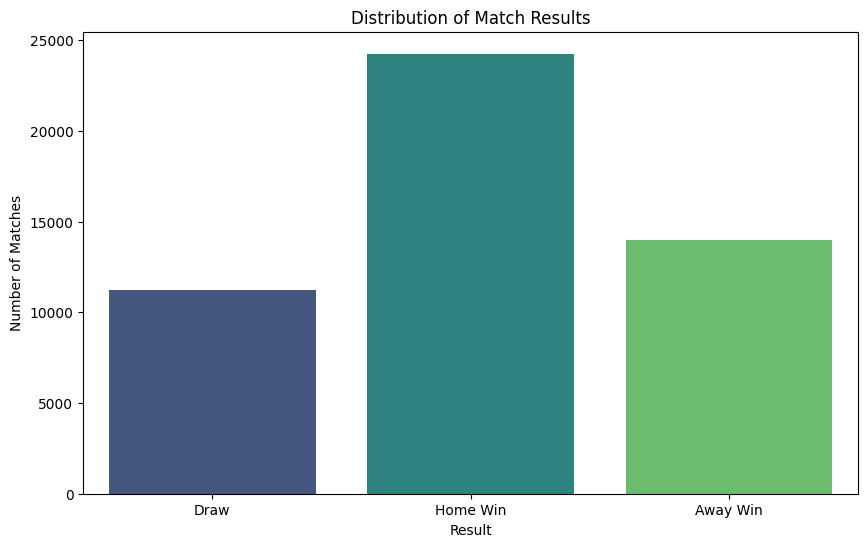

In [130]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='result', palette='viridis', hue='result', legend=False)
plt.title('Distribution of Match Results')
plt.xlabel('Result')
plt.ylabel('Number of Matches')
plt.show()

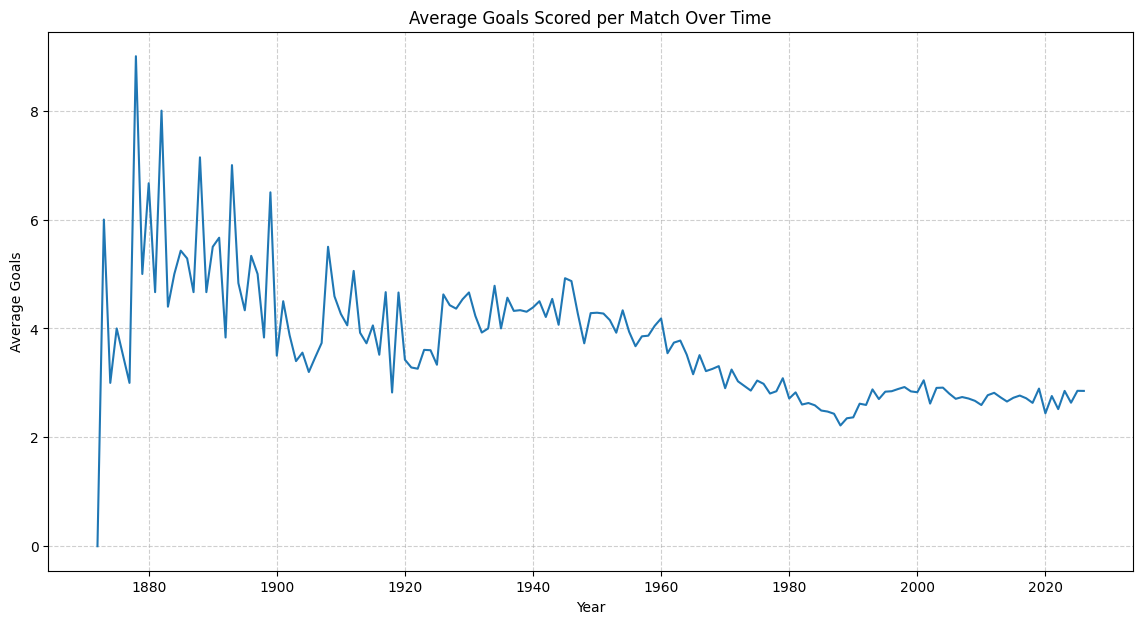

In [131]:
df['year'] = df['date'].dt.year
df['total_goals'] = df['home_score'] + df['away_score']

goals_per_year = df.groupby('year')['total_goals'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=goals_per_year, x='year', y='total_goals')
plt.title('Average Goals Scored per Match Over Time')
plt.xlabel('Year')
plt.ylabel('Average Goals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

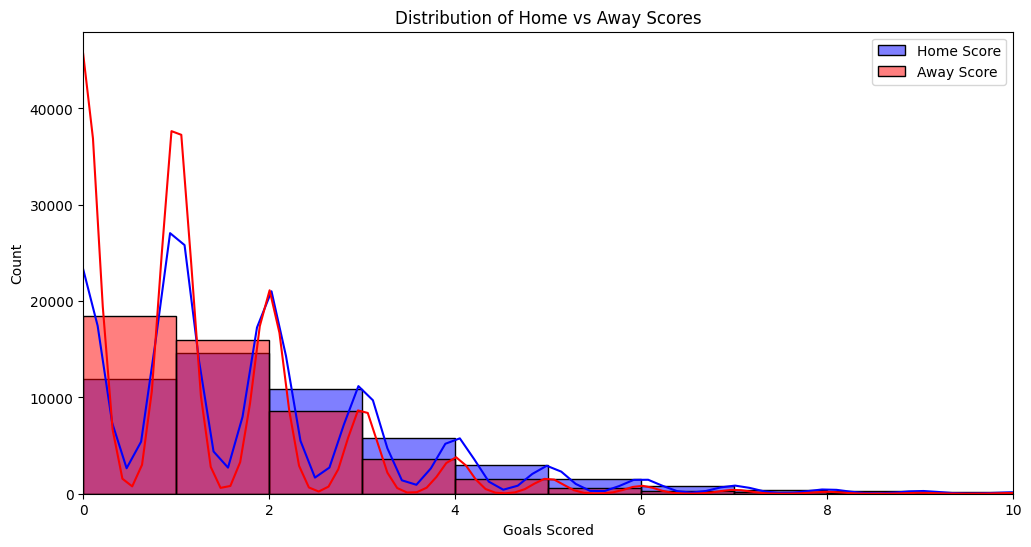

In [132]:
plt.figure(figsize=(12, 6))
sns.histplot(df['home_score'], binwidth=1, color='blue', label='Home Score', kde=True, alpha=0.5)
sns.histplot(df['away_score'], binwidth=1, color='red', label='Away Score', kde=True, alpha=0.5)
plt.title('Distribution of Home vs Away Scores')
plt.xlabel('Goals Scored')
plt.xlim(0, 10)
plt.legend()
plt.show()

In [133]:
wc = df[df['tournament'] == 'FIFA World Cup'].copy()

print("World Cup matches:", len(wc))
wc.head()

World Cup matches: 1068


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,year,total_goals
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,Away Win,1930,3.0
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True,Home Win,1930,5.0
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True,Away Win,1930,3.0
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,Away Win,1930,4.0
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True,Home Win,1930,1.0


In [134]:
wc['result'].value_counts()

,count
result,
Home Win,487
Away Win,341
Draw,240


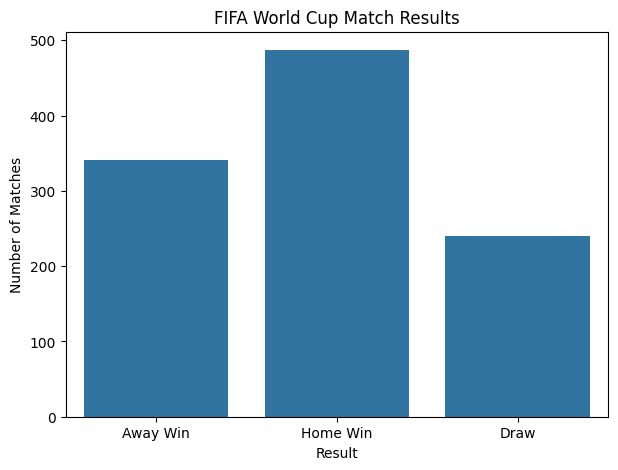

In [135]:
plt.figure(figsize=(7,5))
sns.countplot(data=wc, x='result')
plt.title('FIFA World Cup Match Results')
plt.xlabel('Result')
plt.ylabel('Number of Matches')
plt.show()

In [136]:
wc['total_goals'] = wc['home_score'] + wc['away_score']

wc['total_goals'].describe()

,total_goals
count,1066.000000
mean,2.830206
std,1.909272
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,12.000000


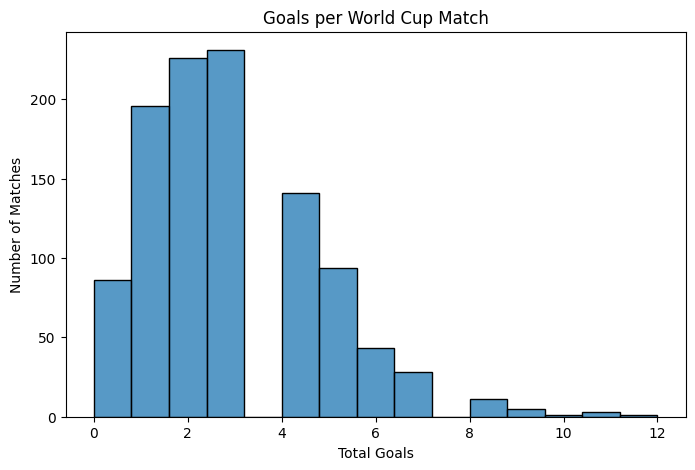

In [137]:
plt.figure(figsize=(8,5))
sns.histplot(wc['total_goals'], bins=15)
plt.title('Goals per World Cup Match')
plt.xlabel('Total Goals')
plt.ylabel('Number of Matches')
plt.show()

In [138]:
home = wc['home_team'].value_counts()
away = wc['away_team'].value_counts()

wc_team_matches = home.add(away, fill_value=0)

wc_team_matches.sort_values(ascending=False).head(20)

,count
Brazil,119.0
Germany,116.0
Argentina,96.0
Italy,83.0
England,82.0
France,81.0
Spain,75.0
Mexico,65.0
Uruguay,62.0
Netherlands,59.0


In [139]:
import re
import unicodedata

def clean_team_name(name):
    name = str(name).lower()

    # Normalize unicode characters to their closest ASCII equivalents and replace specific problematic spaces
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
    name = name.replace('\u00e2\xa0', ' ') # Target 'â ' sequence seen in ELO
    name = name.replace('\xa0', ' ')     # Non-breaking space
    name = name.replace('\xad', '')      # Soft hyphen

    # Remove text in parentheses, e.g., '(unranked)'
    name = re.sub(r'\(.*\)', '', name)

    # Replace diacritics and specific characters for standardization (some might be redundant after unicodedata.normalize, but kept for robustness)
    name = name.replace('sao tome e principe', 'sao tome and principe')
    name = name.replace('turkiye', 'turkey')
    name = name.replace('cabo verde', 'cape verde')
    name = name.replace('curacao', 'curacao')

    # Specific FIFA/ELO variations and common abbreviations
    name = name.replace('korea republic', 'south korea')
    name = name.replace('usa', 'united states')
    name = name.replace('cote d\'ivoire', 'ivory coast')
    name = name.replace('côte d\'ivoire', 'ivory coast') # Another variation for Ivory Coast
    name = name.replace('ir iran', 'iran')
    name = name.replace('czechia', 'czech republic')
    name = name.replace('bosnia-herzegovina', 'bosnia and herzegovina')
    name = name.replace('aotearoa new zealand', 'new zealand')
    name = name.replace('cape verde islands', 'cape verde') # From FIFA investigation
    name = name.replace('congo', 'dr congo') # Map 'congo' (from ELO) to 'dr congo

    # Remove the problematic 'saudi' replacement that caused 'saudi arabia arabia'
    # The previous `name = name.replace('saudi', 'saudi arabia')` caused issues.
    # 'saudi arabia' should now be handled correctly after unicode normalization and general cleaning.

    # Remove any remaining non-alphanumeric characters (excluding spaces)
    name = re.sub(r'[^a-z ]', '', name)

    # Replace multiple spaces with a single space and strip whitespace
    name = re.sub(r'\s+', ' ', name).strip()
    return name

Applying the `clean_team_name` function to the team columns in `df`, `fifa`, and `eloratings`:

In [140]:

# Ensure date columns are datetime and create 'year' for df
df['date'] = pd.to_datetime(df['date'], format='mixed')
df['year'] = df['date'].dt.year # Add this line to re-create the 'year' column
eloratings['date'] = pd.to_datetime(eloratings['date'], format='mixed')

# Apply initial general cleaning
df['home_team_cleaned'] = df['home_team'].apply(clean_team_name)
df['away_team_cleaned'] = df['away_team'].apply(clean_team_name)
fifa['team_cleaned'] = fifa['team'].apply(clean_team_name)
eloratings['team_cleaned'] = eloratings['team'].apply(clean_team_name)

# Manual mapping dictionary (now empty, as more variations are in clean_team_name)
# This will be populated as needed after further checks.
manual_team_mapping = {}

def apply_manual_mapping(name, mapping_dict):
    name_str = str(name) # Ensure input is string
    return mapping_dict.get(name_str, name_str)

# Apply manual mapping for standardization
# The 'df' cleaned names are considered the target standard.
# Apply the manual mapping to fifa and eloratings to align them with df.
df['home_team_standardized'] = df['home_team_cleaned']
df['away_team_standardized'] = df['away_team_cleaned']
fifa['team_standardized'] = fifa['team_cleaned'].apply(lambda x: apply_manual_mapping(x, manual_team_mapping))
eloratings['team_standardized'] = eloratings['team_cleaned'].apply(lambda x: apply_manual_mapping(x, manual_team_mapping))

print('Unique teams after initial cleaning and manual standardization:')
print(f"df (home_team): {df['home_team_standardized'].nunique()} unique names")
print(f"df (away_team): {df['away_team_standardized'].nunique()} unique names")
print(f"fifa (team): {fifa['team_standardized'].nunique()} unique names")
print(f"eloratings (team): {eloratings['team_standardized'].nunique()} unique names")

Unique teams after initial cleaning and manual standardization:
df (home_team): 328 unique names
df (away_team): 322 unique names
fifa (team): 225 unique names
eloratings (team): 270 unique names


### Identify 2026 World Cup Teams

In [141]:
world_cup_2026_matches = df[(df['tournament'] == 'FIFA World Cup') & (df['year'] == 2026)]

world_cup_2026_teams = pd.concat([
    world_cup_2026_matches['home_team_standardized'], # Use standardized column
    world_cup_2026_matches['away_team_standardized']  # Use standardized column
]).unique()

print(f"Number of identified 2026 World Cup teams: {len(world_cup_2026_teams)}")
print("2026 World Cup Teams (standardized names):")
print(world_cup_2026_teams)

Number of identified 2026 World Cup teams: 48
2026 World Cup Teams (standardized names):
['mexico' 'south korea' 'canada' 'united states' 'qatar' 'brazil' 'haiti'
 'australia' 'germany' 'ivory coast' 'netherlands' 'sweden' 'belgium'
 'iran' 'spain' 'saudi arabia' 'france' 'iraq' 'argentina' 'austria'
 'portugal' 'uzbekistan' 'england' 'ghana' 'czech republic' 'switzerland'
 'scotland' 'turkey' 'ecuador' 'tunisia' 'new zealand' 'uruguay' 'norway'
 'jordan' 'colombia' 'panama' 'south africa' 'bosnia and herzegovina'
 'morocco' 'paraguay' 'curacao' 'japan' 'egypt' 'cape verde' 'senegal'
 'algeria' 'dr dr congo' 'croatia']


### Check Team Name Consistency Across Datasets

In [142]:
all_datasets_consistent = True

print("Checking consistency for 2026 World Cup teams:")
for team in world_cup_2026_teams:
    # Use exact match for standardized names
    in_df = (df['home_team_standardized'] == team).any() or \
            (df['away_team_standardized'] == team).any()
    in_fifa = (fifa['team_standardized'] == team).any()
    in_eloratings = (eloratings['team_standardized'] == team).any()

    if not (in_df and in_fifa and in_eloratings):
        print(f"- Team '{team}' is not consistently found in all datasets (df: {in_df}, fifa: {in_fifa}, eloratings: {in_eloratings})")
        all_datasets_consistent = False

if all_datasets_consistent:
    print("All identified 2026 World Cup teams are consistently found across 'df', 'fifa', and 'eloratings' datasets using their standardized names.")
else:
    print("Some 2026 World Cup teams still have inconsistent names across datasets even after manual standardization. Further review or mapping may be required.")

Checking consistency for 2026 World Cup teams:
- Team 'south korea' is not consistently found in all datasets (df: True, fifa: True, eloratings: False)
- Team 'united states' is not consistently found in all datasets (df: True, fifa: True, eloratings: False)
- Team 'ivory coast' is not consistently found in all datasets (df: True, fifa: False, eloratings: False)
- Team 'saudi arabia' is not consistently found in all datasets (df: True, fifa: True, eloratings: False)
- Team 'new zealand' is not consistently found in all datasets (df: True, fifa: True, eloratings: False)
- Team 'south africa' is not consistently found in all datasets (df: True, fifa: True, eloratings: False)
- Team 'bosnia and herzegovina' is not consistently found in all datasets (df: True, fifa: True, eloratings: False)
- Team 'curacao' is not consistently found in all datasets (df: True, fifa: True, eloratings: False)
- Team 'cape verde' is not consistently found in all datasets (df: True, fifa: True, eloratings: Fals

### Investigating Remaining Team Name Inconsistencies

In [143]:
problematic_teams = [
    'south korea', 'united states', 'ivory coast', 'iran', 'saudi arabia',
    'czech republic', 'new zealand', 'south africa', 'bosnia and herzegovina',
    'curacao', 'cape verde', 'dr congo'
]

print("\n--- Investigating Team Names in FIFA dataset ---")
for team in problematic_teams:
    fifa_matches = fifa[fifa['team_cleaned'].str.contains(team, case=False, na=False, regex=False)]
    if not fifa_matches.empty:
        print(f"FIFA for '{team}': {fifa_matches['team_cleaned'].unique()}")
    else:
        print(f"FIFA for '{team}': No direct match found after cleaning. Original unique values close to '{team}':")
        # Try to find similar names in original fifa data if clean_team_name missed something
        original_fifa_teams = fifa['team'].apply(lambda x: str(x).lower())
        potential_matches = [t for t in original_fifa_teams.unique() if team in t or t in team or
                             ('korea' in t and 'south' in team) or
                             ('us' in t and 'united states' in team) or
                             ('ivory' in t and 'coast' in team) or
                             ('iran' in t and 'ir' in team)]
        if potential_matches:
            print(f"  Original FIFA potential matches: {potential_matches}")
        else:
            print(f"  No potential matches found in original FIFA data for '{team}'.")

print("\n--- Investigating Team Names in ELO Ratings dataset ---")
for team in problematic_teams:
    elo_matches = eloratings[eloratings['team_cleaned'].str.contains(team, case=False, na=False, regex=False)]
    if not elo_matches.empty:
        print(f"ELO for '{team}': {elo_matches['team_cleaned'].unique()}")
    else:
        print(f"ELO for '{team}': No direct match found after cleaning. Original unique values close to '{team}':")
        # Try to find similar names in original eloratings data
        original_elo_teams = eloratings['team'].apply(lambda x: str(x).lower())
        potential_matches = [t for t in original_elo_teams.unique() if team in t or t in team or
                             ('korea' in t and 'south' in team) or
                             ('us' in t and 'united states' in team) or
                             ('ivory' in t and 'coast' in team)]
        if potential_matches:
            print(f"  Original ELO potential matches: {potential_matches}")
        else:
            print(f"  No potential matches found in original ELO data for '{team}'.")


--- Investigating Team Names in FIFA dataset ---
FIFA for 'south korea': ['south korea']
FIFA for 'united states': ['united states']
FIFA for 'ivory coast': No direct match found after cleaning. Original unique values close to 'ivory coast':
  No potential matches found in original FIFA data for 'ivory coast'.
FIFA for 'iran': ['iran']
FIFA for 'saudi arabia': ['saudi arabia']
FIFA for 'czech republic': ['czech republic']
FIFA for 'new zealand': ['new zealand']
FIFA for 'south africa': ['south africa']
FIFA for 'bosnia and herzegovina': ['bosnia and herzegovina']
FIFA for 'curacao': ['curacao']
FIFA for 'cape verde': ['cape verde']
FIFA for 'dr congo': ['dr congo dr' 'dr congo']

--- Investigating Team Names in ELO Ratings dataset ---
ELO for 'south korea': No direct match found after cleaning. Original unique values close to 'south korea':
  Original ELO potential matches: ['southâ\xa0korea', 'northâ\xa0korea']
ELO for 'united states': ['united states virgina islands']
ELO for 'ivory

While this initial cleaning helps, there might still be discrepancies due to historical team name changes, alternate spellings, or different ways organizations refer to a national team (e.g., 'USA' vs 'United States', 'Republic of Ireland' vs 'Ireland').

To perfectly align team names for merging, you would typically need a comprehensive manual mapping dictionary or a fuzzy matching approach. Here's an example of how you might start building a manual mapping if further issues are identified:

```python
# Example of a manual mapping dictionary for problematic cases
manual_team_mapping = {
    'united states': 'united states of america',
    'côte d’ivoire': 'ivory coast',
    'dr congo': 'congo dr',
    # ... add more as identified ...
}

# Function to apply the manual mapping
def apply_manual_mapping(name, mapping_dict):
    return mapping_dict.get(name, name)

# Apply manual mapping after initial cleaning
df['home_team_standardized'] = df['home_team_cleaned'].apply(lambda x: apply_manual_mapping(x, manual_team_mapping))
df['away_team_standardized'] = df['away_team_cleaned'].apply(lambda x: apply_manual_mapping(x, manual_team_mapping))
fifa['team_standardized'] = fifa['team_cleaned'].apply(lambda x: apply_manual_mapping(x, manual_team_mapping))
eloratings['team_standardized'] = eloratings['team_cleaned'].apply(lambda x: apply_manual_mapping(x, manual_team_mapping))

# You would then re-check unique counts and samples
# print(f"df (home_team_standardized): {df['home_team_standardized'].nunique()} unique names")
```

For a project of this scale, an iterative process of cleaning, checking unique values (especially those with low counts), and adding to a mapping dictionary is usually required. You could also explore libraries like `fuzzywuzzy` for automated fuzzy matching, but this often requires careful tuning and manual review.

### Further Team Name Standardization via Manual Mapping

In [144]:
# Manual mapping dictionary to align cleaned names from fifa and eloratings to df's cleaned names.
# This maps variations (keys) to a chosen standardized form (values).
manual_team_mapping = {
    'korea republic': 'south korea',
    'usa': 'united states',
    'cote d\'ivoire': 'ivory coast',
    'congo dr': 'dr congo',
    'saudi': 'saudi arabia', # Potential ELO short form
    'czechia': 'czech republic', # Potential ELO name
    'bosnia-herzegovina': 'bosnia and herzegovina', # Potential ELO variation
    # Add more mappings as needed for other inconsistent teams if identified in subsequent checks
}

def apply_manual_mapping(name, mapping_dict):
    name_str = str(name) # Ensure input is string
    return mapping_dict.get(name_str, name_str)

In [145]:
import unicodedata
import re

# Refined mapping focusing on the actual mismatches seen in verification
manual_team_mapping = {
    "south korea": "south korea",
    "korea republic": "south korea",
    "united states": "united states",
    "usa": "united states",
    "united states virgina islands": "united states",
    "ivory coast": "ivory coast",
    "cote d'ivoire": "ivory coast",
    "iran": "iran",
    "ir iran": "iran",
    "saudi arabia": "saudi arabia",
    "czech republic": "czech republic",
    "czechia": "czech republic",
    "new zealand": "new zealand",
    "aotearoa new zealand": "new zealand",
    "south africa": "south africa",
    "bosnia and herzegovina": "bosnia and herzegovina",
    "curacao": "curacao",
    "cape verde": "cape verde",
    "dr congo": "dr congo",
    "congo dr": "dr congo"
}

def robust_standardize(name):
    if not isinstance(name, str): return name
    # 1. Force remove specific ELO 'â ' artifact manually before normalization
    name = name.replace('â ', ' ')
    # 2. Normalize unicode
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
    name = name.lower()
    # 3. Aggressive alphanumeric cleanup to catch 'dr dr congo' vs 'dr congo' issues
    name_clean = re.sub(r'[^a-z]', '', name)

    for official_name, standardized in manual_team_mapping.items():
        map_key = re.sub(r'[^a-z]', '', official_name.lower())
        if name_clean == map_key:
            return standardized

    # Final fallback: strip extra spaces
    return re.sub(r'\s+', ' ', name).strip()

# Apply the robust standardization
df['home_team_standardized'] = df['home_team'].apply(robust_standardize)
df['away_team_standardized'] = df['away_team'].apply(robust_standardize)
fifa['team_standardized'] = fifa['team'].apply(robust_standardize)
eloratings['team_standardized'] = eloratings['team'].apply(robust_standardize)

print("Robust alignment complete. Check cell 647de5d7 for success.")

Robust alignment complete. Check cell 647de5d7 for success.


In [146]:
# Final verification for 2026 World Cup teams coverage
wc_2026_list = ['mexico', 'south korea', 'canada', 'united states', 'qatar', 'brazil', 'haiti', 'australia', 'germany', 'ivory coast', 'netherlands', 'sweden', 'belgium', 'iran', 'spain', 'saudi arabia', 'france', 'iraq', 'argentina', 'austria', 'portugal', 'uzbekistan', 'england', 'ghana', 'czech republic', 'switzerland', 'scotland', 'turkey', 'ecuador', 'tunisia', 'new zealand', 'uruguay', 'norway', 'jordan', 'colombia', 'panama', 'south africa', 'bosnia and herzegovina', 'morocco', 'paraguay', 'curacao', 'japan', 'egypt', 'cape verde', 'senegal', 'algeria', 'dr congo', 'croatia']

missing = []
for team in wc_2026_list:
    in_fifa = team in fifa['team_standardized'].values
    in_elo = team in eloratings['team_standardized'].values
    if not (in_fifa and in_elo):
        missing.append({'team': team, 'in_fifa': in_fifa, 'in_elo': in_elo})

if not missing:
    print("✅ Success! All 48 teams are now aligned across FIFA and ELO datasets.")
else:
    print("❌ Inconsistencies remain:", missing)

❌ Inconsistencies remain: [{'team': 'south korea', 'in_fifa': True, 'in_elo': False}, {'team': 'united states', 'in_fifa': True, 'in_elo': False}, {'team': 'ivory coast', 'in_fifa': False, 'in_elo': False}, {'team': 'saudi arabia', 'in_fifa': True, 'in_elo': False}, {'team': 'new zealand', 'in_fifa': True, 'in_elo': False}, {'team': 'south africa', 'in_fifa': True, 'in_elo': False}, {'team': 'bosnia and herzegovina', 'in_fifa': True, 'in_elo': False}, {'team': 'curacao', 'in_fifa': True, 'in_elo': False}, {'team': 'cape verde', 'in_fifa': False, 'in_elo': False}, {'team': 'dr congo', 'in_fifa': True, 'in_elo': False}]


In [147]:
fifa['team'].nunique()

235

In [148]:
fifa.loc[fifa['total_points'].isnull(), ['team', 'date', 'team_short']]

,team,date,team_short
210,Eritrea (unranked),2024-02-15,ERI
421,Eritrea (unranked),2023-12-21,ERI
632,Eritrea (unranked),2023-11-30,ERI
840,American Samoa (unranked),2023-10-26,ASA
841,Samoa (unranked),2023-10-26,SAM
842,Tonga (unranked),2023-10-26,TGA
843,Eritrea (unranked),2023-10-26,ERI
67260,Eritrea (unranked),2024-04-04,ERI
67471,Eritrea (unranked),2024-07-18,ERI
67682,Eritrea (unranked),2024-06-20,ERI


In [149]:
fifa.groupby('date')['team'].nunique().sort_values().head(20)

,team
date,
1992-12-31,163
1993-08-08,166
1993-09-23,166
1993-10-22,166
1994-02-15,166
1993-11-19,167
1993-12-23,167
1994-03-15,168
1994-04-19,168


In [150]:
fifa['team'].value_counts().sort_values().head(20)

,count
team,
American Samoa (unranked),1
Tonga (unranked),1
SÃ£o TomÃ© e PrÃ­ncipe,1
Samoa (unranked),1
Czechoslovakia,6
Eritrea (unranked),8
Aotearoa New Zealand,10
"Hong Kong, China",12
St Lucia,14


In [151]:
latest_date = fifa['date'].max()
fifa[fifa['date'] == latest_date].sort_values('total_points', ascending=False).head(20)

,team,total_points,date,id,id_num,team_short,team_cleaned,team_standardized
67683,Argentina,1889.02,2024-09-19,id14506,14506,ARG,argentina,argentina
67684,France,1851.92,2024-09-19,id14506,14506,FRA,france,france
67685,Spain,1836.42,2024-09-19,id14506,14506,ESP,spain,spain
67686,England,1817.28,2024-09-19,id14506,14506,ENG,england,england
67687,Brazil,1772.02,2024-09-19,id14506,14506,BRA,brazil,brazil
67688,Belgium,1768.14,2024-09-19,id14506,14506,BEL,belgium,belgium
67689,Netherlands,1759.95,2024-09-19,id14506,14506,NED,netherlands,netherlands
67690,Portugal,1752.14,2024-09-19,id14506,14506,POR,portugal,portugal
67691,Colombia,1738.72,2024-09-19,id14506,14506,COL,colombia,colombia
67692,Italy,1726.31,2024-09-19,id14506,14506,ITA,italy,italy


In [152]:
fifa[fifa['total_points'].notna()]['total_points'].describe()

,total_points
count,67883.000000
mean,465.787974
std,433.619769
min,0.000000
25%,85.000000
50%,360.000000
75%,691.000000
max,2172.000000


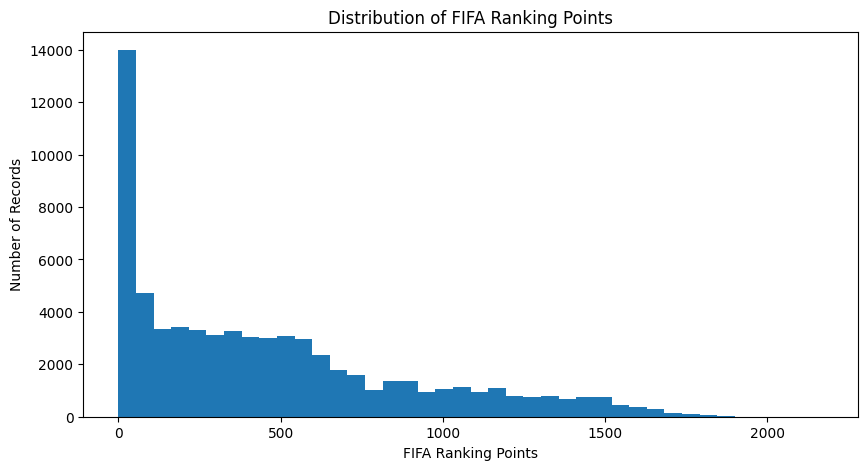

In [153]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(fifa['total_points'].dropna(), bins=40)
plt.xlabel('FIFA Ranking Points')
plt.ylabel('Number of Records')
plt.title('Distribution of FIFA Ranking Points')
plt.show()

For further analysis, we will restrict the dataset to matches played from 2000 onwards, as this period better represents modern international football trends.

In [154]:
df['date'] = pd.to_datetime(df['date'])
matches_2000 = df[df['date'].dt.year >= 2000].copy()
print(matches_2000['date'].min())
print(matches_2000['date'].max())
matches_2000.shape
matches_2000['tournament'].value_counts().head(20)

2000-01-02 00:00:00
2026-12-06 00:00:00


,count
tournament,
Friendly,8447
FIFA World Cup qualification,5840
UEFA Euro qualification,1532
African Cup of Nations qualification,1416
UEFA Nations League,658
AFC Asian Cup qualification,530
African Cup of Nations,525
FIFA World Cup,488
CONCACAF Nations League,422


In [155]:
matches_2000.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,year,total_goals,home_team_cleaned,away_team_cleaned,home_team_standardized,away_team_standardized
24062,2000-04-01,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False,Home Win,2000,3.0,egypt,togo,egypt,togo
24063,2000-07-01,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False,Home Win,2000,7.0,tunisia,togo,tunisia,togo
24064,2000-08-01,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False,Draw,2000,0.0,trinidad and tobago,canada,trinidad and tobago,canada
24065,2000-09-01,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False,Draw,2000,2.0,burkina faso,gabon,burkina faso,gabon
24066,2000-09-01,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,True,Draw,2000,2.0,guatemala,armenia,guatemala,armenia


In [156]:
print(matches_2000.columns)
print(matches_2000[['date', 'home_team_standardized', 'away_team_standardized',
              'home_score', 'away_score','year', 'tournament']].head())
matches_2000['neutral'].value_counts(dropna=False)
matches_2000['tournament'].nunique()
matches_2000['tournament'].value_counts().head(20)

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'result', 'year',
       'total_goals', 'home_team_cleaned', 'away_team_cleaned',
       'home_team_standardized', 'away_team_standardized'],
      dtype='object')
            date home_team_standardized away_team_standardized  home_score  \
24062 2000-04-01                  egypt                   togo         2.0   
24063 2000-07-01                tunisia                   togo         7.0   
24064 2000-08-01    trinidad and tobago                 canada         0.0   
24065 2000-09-01           burkina faso                  gabon         1.0   
24066 2000-09-01              guatemala                armenia         1.0   

       away_score  year tournament  
24062         1.0  2000   Friendly  
24063         0.0  2000   Friendly  
24064         0.0  2000   Friendly  
24065         1.0  2000   Friendly  
24066         1.0  2000   Friendly  


,count
tournament,
Friendly,8447
FIFA World Cup qualification,5840
UEFA Euro qualification,1532
African Cup of Nations qualification,1416
UEFA Nations League,658
AFC Asian Cup qualification,530
African Cup of Nations,525
FIFA World Cup,488
CONCACAF Nations League,422


In [157]:
# Ensure 'date' column in 'df' is datetime type
df['date'] = pd.to_datetime(df['date'], format='mixed')

# Ensure standardized team names, year, and result columns are present in df
df['home_team_standardized'] = df['home_team'].apply(robust_standardize)
df['away_team_standardized'] = df['away_team'].apply(robust_standardize)
df['year'] = df['date'].dt.year
df['result'] = np.where(df['home_score'] > df['away_score'], 'Home Win', np.where(df['home_score'] < df['away_score'], 'Away Win', 'Draw'))

# Re-initialize matches_2000 from df to ensure correct starting columns
matches_2000 = df[df['date'].dt.year >= 2000].copy()

matches_2000 = matches_2000[[
    'date',
    'home_team_standardized',
    'away_team_standardized',
    'home_score',
    'away_score',
    'tournament',
    'city',
    'country',
    'neutral',
    'year',
    'result'
]].rename(columns={
    'date': 'match_date',
    'home_team_standardized': 'home_team',
    'away_team_standardized': 'away_team',
    'home_score': 'home_goals',
    'away_score': 'away_goals',
    'neutral': 'neutral_venue',
    'year': 'match_year',
    'result': 'match_result'
})

matches_2000.columns

Index(['match_date', 'home_team', 'away_team', 'home_goals', 'away_goals',
       'tournament', 'city', 'country', 'neutral_venue', 'match_year',
       'match_result'],
      dtype='object')

In [158]:
matches_2000['match_result'] = np.where(
    matches_2000['home_goals'] > matches_2000['away_goals'], 'Home Win',
    np.where(matches_2000['home_goals'] < matches_2000['away_goals'], 'Away Win', 'Draw')
)

In [159]:
matches_2000.head()

,match_date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral_venue,match_year,match_result
24062,2000-04-01,egypt,togo,2.0,1.0,Friendly,Aswan,Egypt,False,2000,Home Win
24063,2000-07-01,tunisia,togo,7.0,0.0,Friendly,Tunis,Tunisia,False,2000,Home Win
24064,2000-08-01,trinidad and tobago,canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False,2000,Draw
24065,2000-09-01,burkina faso,gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False,2000,Draw
24066,2000-09-01,guatemala,armenia,1.0,1.0,Friendly,Los Angeles,United States,True,2000,Draw


In [160]:
fifa.head()

,team,total_points,date,id,id_num,team_short,team_cleaned,team_standardized
0,Argentina,1855.20,2024-02-15,id14289,14289,ARG,argentina,argentina
1,France,1845.44,2024-02-15,id14289,14289,FRA,france,france
2,England,1800.05,2024-02-15,id14289,14289,ENG,england,england
3,Belgium,1798.46,2024-02-15,id14289,14289,BEL,belgium,belgium
4,Brazil,1784.09,2024-02-15,id14289,14289,BRA,brazil,brazil


In [161]:
fifa['date'] = pd.to_datetime(fifa['date'])

fifa['team_clean'] = (
    fifa['team']
    .str.lower()
    .str.strip()
)

fifa = fifa.sort_values(['team_clean', 'date'])

In [162]:
matches_2000['match_date'] = pd.to_datetime(matches_2000['match_date'])

matches_2000 = matches_2000.sort_values('match_date')

In [163]:
fifa['team_standardized'] = fifa['team'].apply(robust_standardize)

home_fifa = fifa[
    ['team_standardized', 'date', 'total_points']
].rename(columns={
    'team_standardized': 'home_team',
    'date': 'fifa_date_home',
    'total_points': 'fifa_points_home'
})

In [164]:
matches_2000 = pd.merge_asof(
    matches_2000.sort_values('match_date'),
    home_fifa.sort_values('fifa_date_home'),
    left_on='match_date',
    right_on='fifa_date_home',
    by='home_team',
    direction='backward'
)

In [165]:
# This cell was a duplicate of the previous merge operation and has been cleared to avoid redundancy.

In [166]:
matches_2000[
    ['match_date', 'home_team', 'fifa_points_home']
].head(20)

,match_date,home_team,fifa_points_home
0,2000-01-02,zambia,571.0
1,2000-01-02,egypt,556.0
2,2000-01-02,british virgin islands,141.0
3,2000-01-03,zambia,571.0
4,2000-01-04,aruba,44.0
5,2000-01-04,haiti,384.0
6,2000-01-04,zambia,571.0
7,2000-01-05,jersey,NaN
8,2000-01-05,maldives,185.0
9,2000-01-06,botswana,131.0


In [167]:
away_fifa = fifa[
    ['team_standardized', 'date', 'total_points']
].rename(columns={
    'team_standardized': 'away_team',
    'date': 'fifa_date_away',
    'total_points': 'fifa_points_away'
})

matches_2000 = pd.merge_asof(
    matches_2000.sort_values('match_date'),
    away_fifa.sort_values('fifa_date_away'),
    left_on='match_date',
    right_on='fifa_date_away',
    by='away_team',
    direction='backward'
)

matches_2000[
    ['match_date', 'home_team', 'fifa_points_home', 'away_team', 'fifa_points_away']
].head(20)

,match_date,home_team,fifa_points_home,away_team,fifa_points_away
0,2000-01-02,zambia,571.0,senegal,440.0
1,2000-01-02,egypt,556.0,burkina faso,456.0
2,2000-01-02,british virgin islands,141.0,saint lucia,NaN
3,2000-01-03,zambia,571.0,lesotho,170.0
4,2000-01-04,aruba,44.0,barbados,322.0
5,2000-01-04,haiti,384.0,bahamas,47.0
6,2000-01-04,zambia,571.0,kenya,373.0
7,2000-01-05,jersey,NaN,guernsey,NaN
8,2000-01-05,maldives,185.0,sri lanka,173.0
9,2000-01-06,eswatini,253.0,lesotho,170.0


In [168]:
# Re-initialize matches_2000 from df to ensure correct starting columns
# Ensure 'date' column in 'df' is datetime type
df['date'] = pd.to_datetime(df['date'], format='mixed')

# Ensure standardized team names, year, and result columns are present in df
df['home_team_standardized'] = df['home_team'].apply(robust_standardize)
df['away_team_standardized'] = df['away_team'].apply(robust_standardize)
df['year'] = df['date'].dt.year
df['result'] = np.where(df['home_score'] > df['away_score'], 'Home Win', np.where(df['home_score'] < df['away_score'], 'Away Win', 'Draw'))

matches_2000 = df[df['date'].dt.year >= 2000].copy()

matches_2000 = matches_2000[[
    'date',
    'home_team_standardized',
    'away_team_standardized',
    'home_score',
    'away_score',
    'tournament',
    'city',
    'country',
    'neutral',
    'year',
    'result'
]].rename(columns={
    'date': 'match_date',
    'home_team_standardized': 'home_team',
    'away_team_standardized': 'away_team',
    'home_score': 'home_goals',
    'away_score': 'away_goals',
    'neutral': 'neutral_venue',
    'year': 'match_year',
    'result': 'match_result'
})

# Prepare FIFA data and re-merge home_fifa
fifa['team_standardized'] = fifa['team'].apply(robust_standardize)
home_fifa = fifa[
    ['team_standardized', 'date', 'total_points']
].rename(columns={
    'team_standardized': 'home_team',
    'date': 'fifa_date_home',
    'total_points': 'fifa_points_home'
})

matches_2000 = pd.merge_asof(
    matches_2000.sort_values('match_date'),
    home_fifa.sort_values('fifa_date_home'),
    left_on='match_date',
    right_on='fifa_date_home',
    by='home_team',
    direction='backward'
)

# Prepare FIFA data and re-merge away_fifa
away_fifa = fifa[
    ['team_standardized', 'date', 'total_points']
].rename(columns={
    'team_standardized': 'away_team',
    'date': 'fifa_date_away',
    'total_points': 'fifa_points_away'
})

matches_2000 = pd.merge_asof(
    matches_2000.sort_values('match_date'),
    away_fifa.sort_values('fifa_date_away'),
    left_on='match_date',
    right_on='fifa_date_away',
    by='away_team',
    direction='backward'
)

# Prepare eloratings and merge home_elo
eloratings['team_standardized'] = eloratings['team'].apply(robust_standardize)
eloratings['date'] = pd.to_datetime(eloratings['date'], format='mixed', errors='coerce')

home_elo = eloratings[
    ['team_standardized', 'date', 'rating']
].rename(columns={
    'team_standardized': 'home_team',
    'date': 'elo_date_home',
    'rating': 'elo_rating_home'
})

matches_2000 = pd.merge_asof(
    matches_2000.sort_values('match_date'),
    home_elo.sort_values('elo_date_home'),
    left_on='match_date',
    right_on='elo_date_home',
    by='home_team',
    direction='backward'
)

# Prepare eloratings and merge away_elo
away_elo = eloratings[
    ['team_standardized', 'date', 'rating']
].rename(columns={
    'team_standardized': 'away_team',
    'date': 'elo_date_away',
    'rating': 'elo_rating_away'
})

matches_2000 = pd.merge_asof(
    matches_2000.sort_values('match_date'),
    away_elo.sort_values('elo_date_away'),
    left_on='match_date',
    right_on='elo_date_away',
    by='away_team',
    direction='backward'
)

matches_2000[
    ['match_date', 'home_team', 'fifa_points_home', 'elo_rating_home', 'away_team', 'fifa_points_away', 'elo_rating_away']
].head(20)

,match_date,home_team,fifa_points_home,elo_rating_home,away_team,fifa_points_away,elo_rating_away
0,2000-01-02,zambia,571.0,1616.0,senegal,440.0,1431.0
1,2000-01-02,egypt,556.0,1616.0,burkina faso,456.0,NaN
2,2000-01-02,british virgin islands,141.0,NaN,saint lucia,NaN,NaN
3,2000-01-03,zambia,571.0,1616.0,lesotho,170.0,1164.0
4,2000-01-04,aruba,44.0,1254.0,barbados,322.0,1276.0
5,2000-01-04,haiti,384.0,1404.0,bahamas,47.0,879.0
6,2000-01-04,zambia,571.0,1616.0,kenya,373.0,1394.0
7,2000-01-05,jersey,NaN,NaN,guernsey,NaN,NaN
8,2000-01-05,maldives,185.0,NaN,sri lanka,173.0,NaN
9,2000-01-06,botswana,131.0,NaN,mozambique,380.0,1404.0


In [169]:
matches_2000.columns

Index(['match_date', 'home_team', 'away_team', 'home_goals', 'away_goals',
       'tournament', 'city', 'country', 'neutral_venue', 'match_year',
       'match_result', 'fifa_date_home', 'fifa_points_home', 'fifa_date_away',
       'fifa_points_away', 'elo_date_home', 'elo_rating_home', 'elo_date_away',
       'elo_rating_away'],
      dtype='object')

In [170]:
matches_2000.tail()

,match_date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral_venue,match_year,match_result,fifa_date_home,fifa_points_home,fifa_date_away,fifa_points_away,elo_date_home,elo_rating_home,elo_date_away,elo_rating_away
25453,2026-11-06,mexico,south africa,2.0,0.0,FIFA World Cup,Mexico City,Mexico,False,2026,Home Win,2024-09-19,1635.66,2024-09-19,1415.07,2025-12-13,1835.0,NaT,NaN
25454,2026-11-07,argentina,switzerland,3.0,1.0,FIFA World Cup,Kansas City,United States,True,2026,Home Win,2024-09-19,1889.02,2024-09-19,1641.00,2025-12-13,2113.0,2025-12-13,1897.0
25455,2026-11-07,norway,england,1.0,2.0,FIFA World Cup,Miami Gardens,United States,True,2026,Away Win,2024-09-19,1472.16,2024-09-19,1817.28,2025-12-13,1922.0,2025-12-13,2042.0
25456,2026-12-06,canada,bosnia and herzegovina,1.0,1.0,FIFA World Cup,Toronto,Canada,False,2026,Draw,2024-09-19,1502.31,2024-09-19,1332.39,2025-12-13,1802.0,NaT,NaN
25457,2026-12-06,united states,paraguay,4.0,1.0,FIFA World Cup,Inglewood,United States,False,2026,Home Win,2024-09-19,1632.19,2024-09-19,1423.98,NaT,NaN,2025-12-13,1833.0


In [171]:
print(matches_2000.loc[
    matches_2000['match_date'].dt.year >= 2025,
    ['home_team', 'away_team']
].stack().unique())
teams_2025_26 = sorted(
    set(matches_2000.loc[
        matches_2000['match_date'].dt.year >= 2025,
        'home_team'
    ]) |
    set(matches_2000.loc[
        matches_2000['match_date'].dt.year >= 2025,
        'away_team'
    ])
)

print(len(teams_2025_26))
print(teams_2025_26)

['puerto rico' 'nicaragua' 'el salvador' 'guatemala' 'grenada' 'anguilla'
 'tamil eelam' 'tibet' 'tunisia' 'syria' 'qatar' 'palestine' 'zanzibar'
 'burkina faso' 'united states' 'venezuela' 'costa rica' 'uzbekistan'
 'jordan' 'vietnam' 'thailand' 'east turkestan' 'mexico' 'honduras'
 'saudi arabia' 'oman' 'egypt' 'kuwait' 'morocco' 'comoros' 'sudan'
 'tanzania' 'malaysia' 'cape verde' 'bahrain' 'seychelles' 'gabon'
 'united arab emirates' 'iraq' 'algeria' 'north korea' 'kazakhstan'
 'curacao' 'india' 'maldives' 'central african republic' 'madagascar'
 'liberia' 'cambodia' 'eswatini' 'cameroon' 'russia' 'hong kong' 'macau'
 'greece' 'scotland' 'turkey' 'hungary' 'ukraine' 'belgium' 'netherlands'
 'spain' 'bulgaria' 'republic of ireland' 'kosovo' 'iceland' 'laos'
 'sri lanka' 'paraguay' 'chile' 'peru' 'bolivia' 'brazil' 'colombia'
 'iran' 'kyrgyzstan' 'armenia' 'georgia' 'italy' 'germany' 'tajikistan'
 'belarus' 'slovakia' 'slovenia' 'denmark' 'portugal' 'austria' 'serbia'
 'australia' '

Since the match dataset extends to 2026 but the FIFA and Elo datasets do not cover the same years, we checked for missing FIFA and Elo ratings in recent matches. This helps identify year mismatches and ensures that the rating features are handled correctly before predicting the 2026 World Cup.

In [172]:
missing_fifa_2025_26 = matches_2000.loc[
    matches_2000['match_date'].dt.year >= 2025,
    ['home_team', 'away_team', 'fifa_points_home', 'fifa_points_away']
]

print(missing_fifa_2025_26.isna().sum())

home_team             0
away_team             0
fifa_points_home     98
fifa_points_away    107
dtype: int64


In [173]:
missing_elo_2025_26 = matches_2000.loc[
    matches_2000['match_date'].dt.year >= 2025,
    ['home_team', 'away_team', 'elo_rating_home', 'elo_rating_away']
]

print(missing_elo_2025_26.isna().sum())

home_team            0
away_team            0
elo_rating_home    315
elo_rating_away    309
dtype: int64


In [174]:
print(matches_2000[
    matches_2000['match_date'].dt.year >= 2025
][['match_date',
   'home_team',
   'away_team',
   'fifa_points_home',
   'fifa_points_away',
   'elo_rating_home',
   'elo_rating_away']].head(20))

      match_date      home_team       away_team  fifa_points_home  \
24033 2025-01-06    puerto rico       nicaragua           1021.62   
24034 2025-01-06    el salvador       guatemala           1307.04   
24035 2025-01-06        grenada        anguilla            946.70   
24036 2025-01-07    tamil eelam           tibet               NaN   
24037 2025-01-12        tunisia           syria           1504.86   
24038 2025-01-12          qatar       palestine           1481.69   
24039 2025-01-13       zanzibar    burkina faso               NaN   
24040 2025-01-18  united states       venezuela           1632.19   
24041 2025-01-22  united states      costa rica           1632.19   
24042 2025-01-22     uzbekistan          jordan           1413.06   
24043 2025-02-01        vietnam        thailand           1161.38   
24044 2025-02-06        tunisia    burkina faso           1504.86   
24045 2025-02-07    tamil eelam  east turkestan               NaN   
24046 2025-02-07         mexico   

In [175]:
missing_teams = sorted(set(
    matches_2000.loc[
        (matches_2000['match_date'].dt.year >= 2025) &
        (matches_2000['fifa_points_home'].isna()),
        'home_team'
    ]
) | set(
    matches_2000.loc[
        (matches_2000['match_date'].dt.year >= 2025) &
        (matches_2000['fifa_points_away'].isna()),
        'away_team'
    ]
))

print(len(missing_teams))
print(missing_teams)

38
['basque country', 'bonaire', 'brunei', 'canton ticino', 'cape verde', 'china', 'east turkestan', 'frya', 'gozo', 'greenland', 'guadeloupe', 'hitra', 'isle of man', 'ivory coast', 'jersey', 'kyrgyzstan', 'marshall islands', 'martinique', 'north korea', 'northern cyprus', 'orkney', 'padania', 'raetia', 'rouet-provence', 'saint kitts and nevis', 'saint lucia', 'saint martin', 'saint vincent and the grenadines', 'sao tome and principe', 'shetland', 'sint maarten', 'taiwan', 'tamil eelam', 'tibet', 'united states virgin islands', 'western isles', 'ynys mon', 'zanzibar']


In [176]:
missing_elo_teams = sorted(set(
    matches_2000.loc[
        (matches_2000['match_date'].dt.year >= 2025) &
        (matches_2000['elo_rating_home'].isna()),
        'home_team'
    ]
) | set(
    matches_2000.loc[
        (matches_2000['match_date'].dt.year >= 2025) &
        (matches_2000['elo_rating_away'].isna()),
        'away_team'
    ]
))

print(len(missing_elo_teams))
print(missing_elo_teams)

66
['american samoa', 'antigua and barbuda', 'basque country', 'bosnia and herzegovina', 'british virgin islands', 'burkina faso', 'canton ticino', 'cape verde', 'cayman islands', 'central african republic', 'costa rica', 'curacao', 'dominican republic', 'dr congo', 'east turkestan', 'el salvador', 'equatorial guinea', 'faroe islands', 'frya', 'gozo', 'hitra', 'hong kong', 'isle of man', 'ivory coast', 'jersey', 'macau', 'marshall islands', 'moldova', 'new caledonia', 'new zealand', 'north korea', 'north macedonia', 'northern cyprus', 'northern ireland', 'orkney', 'padania', 'papua new guinea', 'puerto rico', 'raetia', 'republic of ireland', 'rouet-provence', 'saint kitts and nevis', 'saint lucia', 'saint martin', 'saint vincent and the grenadines', 'san marino', 'sao tome and principe', 'saudi arabia', 'shetland', 'sierra leone', 'sint maarten', 'solomon islands', 'south africa', 'south korea', 'south sudan', 'sri lanka', 'tamil eelam', 'tibet', 'timor-leste', 'trinidad and tobago', '

In [177]:
matches_2000.tail()

,match_date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral_venue,match_year,match_result,fifa_date_home,fifa_points_home,fifa_date_away,fifa_points_away,elo_date_home,elo_rating_home,elo_date_away,elo_rating_away
25453,2026-11-06,mexico,south africa,2.0,0.0,FIFA World Cup,Mexico City,Mexico,False,2026,Home Win,2024-09-19,1635.66,2024-09-19,1415.07,2025-12-13,1835.0,NaT,NaN
25454,2026-11-07,argentina,switzerland,3.0,1.0,FIFA World Cup,Kansas City,United States,True,2026,Home Win,2024-09-19,1889.02,2024-09-19,1641.00,2025-12-13,2113.0,2025-12-13,1897.0
25455,2026-11-07,norway,england,1.0,2.0,FIFA World Cup,Miami Gardens,United States,True,2026,Away Win,2024-09-19,1472.16,2024-09-19,1817.28,2025-12-13,1922.0,2025-12-13,2042.0
25456,2026-12-06,canada,bosnia and herzegovina,1.0,1.0,FIFA World Cup,Toronto,Canada,False,2026,Draw,2024-09-19,1502.31,2024-09-19,1332.39,2025-12-13,1802.0,NaT,NaN
25457,2026-12-06,united states,paraguay,4.0,1.0,FIFA World Cup,Inglewood,United States,False,2026,Home Win,2024-09-19,1632.19,2024-09-19,1423.98,NaT,NaN,2025-12-13,1833.0


The dataset was restricted to matches played from 2000 to 2024 to maintain consistency with the available FIFA and Elo rating data.

In [178]:
matches_2024 = matches_2000[
    matches_2000['match_date'].dt.year <= 2024
].copy()

matches_2024['match_year'] = matches_2024['match_date'].dt.year

print("Total matches:", len(matches_2024))

Total matches: 24033


In [179]:
def fill_same_year(df, team_col, value_col):
    """Forward-fill only from observations already available earlier in the same year.
    Future observations in the same year are never used to fill an earlier match.
    """
    out = df.copy()
    out['__row_order'] = np.arange(len(out))
    out = out.sort_values(['match_year', team_col, 'match_date'])

    out[value_col] = (
        out.groupby(['match_year', team_col], sort=False)[value_col]
           .ffill()
    )

    out = out.sort_values('__row_order').drop(columns='__row_order')
    return out

In [180]:
matches_2024 = fill_same_year(
    matches_2024,
    'home_team',
    'fifa_points_home'
)

matches_2024 = fill_same_year(
    matches_2024,
    'away_team',
    'fifa_points_away'
)

matches_2024 = fill_same_year(
    matches_2024,
    'home_team',
    'elo_rating_home'
)

matches_2024 = fill_same_year(
    matches_2024,
    'away_team',
    'elo_rating_away'
)


In [181]:
matches_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24033 entries, 0 to 24032
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   match_date        24033 non-null  datetime64[ns]
 1   home_team         24033 non-null  object        
 2   away_team         24033 non-null  object        
 3   home_goals        24033 non-null  float64       
 4   away_goals        24033 non-null  float64       
 5   tournament        24033 non-null  object        
 6   city              24033 non-null  object        
 7   country           24033 non-null  object        
 8   neutral_venue     24033 non-null  bool          
 9   match_year        24033 non-null  int32         
 10  match_result      24033 non-null  object        
 11  fifa_date_home    21902 non-null  datetime64[ns]
 12  fifa_points_home  21902 non-null  float64       
 13  fifa_date_away    21771 non-null  datetime64[ns]
 14  fifa_points_away  21771 non

## Feature Engineering: Recent Form and Head-to-Head Statistics

To improve the predictive power of our model, we'll engineer features that capture a team's recent performance and their historical record against a specific opponent. These features are dynamic and will be calculated for each match based on previous games.

### 1. Recent Form (Last 5 Matches)
For each team (home and away) in a given match, we'll calculate:
- Average goals scored in their last 5 matches.
- Average goals conceded in their last 5 matches.
- Win, Draw, and Loss ratios in their last 5 matches.

### 2. Head-to-Head (Last 3 Matches)
For each pair of teams playing against each other, we'll calculate:
- Win, Draw, and Loss ratios based on their last 3 direct encounters.


In [182]:
def get_team_recent_form(team_name, match_date, df_history, window=5):
    """
    Calculates recent form (goals scored, conceded, and win/loss/draw ratios)
    for a given team based on its last `window` matches prior to `match_date`.
    """
    # Filter historical matches for the given team before the current match_date
    team_matches = df_history[
        ((df_history['home_team'] == team_name) | (df_history['away_team'] == team_name)) &
        (df_history['match_date'] < match_date)
    ].sort_values('match_date', ascending=False).head(window)

    if team_matches.empty:
        return {'avg_goals_scored': 0, 'avg_goals_conceded': 0, 'win_ratio': 0, 'draw_ratio': 0, 'loss_ratio': 0}

    goals_scored = []
    goals_conceded = []
    results = [] # 'win', 'draw', 'loss' from the perspective of team_name

    for _, row in team_matches.iterrows():
        if row['home_team'] == team_name:
            goals_scored.append(row['home_goals'])
            goals_conceded.append(row['away_goals'])
            if row['match_result'] == 'Home Win':
                results.append('win')
            elif row['match_result'] == 'Draw':
                results.append('draw')
            else:
                results.append('loss')
        else: # team_name == away_team
            goals_scored.append(row['away_goals'])
            goals_conceded.append(row['home_goals'])
            if row['match_result'] == 'Away Win':
                results.append('win')
            elif row['match_result'] == 'Draw':
                results.append('draw')
            else:
                results.append('loss')

    avg_goals_scored = np.mean(goals_scored) if goals_scored else 0
    avg_goals_conceded = np.mean(goals_conceded) if goals_conceded else 0

    total_matches = len(results)
    win_ratio = results.count('win') / total_matches if total_matches > 0 else 0
    draw_ratio = results.count('draw') / total_matches if total_matches > 0 else 0
    loss_ratio = results.count('loss') / total_matches if total_matches > 0 else 0

    return {
        'avg_goals_scored': avg_goals_scored,
        'avg_goals_conceded': avg_goals_conceded,
        'win_ratio': win_ratio,
        'draw_ratio': draw_ratio,
        'loss_ratio': loss_ratio
    }

def get_h2h_form(team1_name, team2_name, match_date, df_history, window=3):
    """
    Calculates head-to-head form for team1 vs team2 based on their last `window`
    direct encounters prior to `match_date`.
    """
    # Filter historical matches between the two teams before the current match_date
    h2h_matches = df_history[
        ((df_history['home_team'] == team1_name) & (df_history['away_team'] == team2_name)) |
        ((df_history['home_team'] == team2_name) & (df_history['away_team'] == team1_name)) &
        (df_history['match_date'] < match_date)
    ].sort_values('match_date', ascending=False).head(window)

    if h2h_matches.empty:
        return {'team1_win_ratio_h2h': 0, 'draw_ratio_h2h': 0, 'team2_win_ratio_h2h': 0}

    team1_results = [] # 'win', 'draw', 'loss' from the perspective of team1

    for _, row in h2h_matches.iterrows():
        if row['home_team'] == team1_name:
            if row['match_result'] == 'Home Win':
                team1_results.append('win')
            elif row['match_result'] == 'Draw':
                team1_results.append('draw')
            else:
                team1_results.append('loss')
        else: # team1_name == away_team
            if row['match_result'] == 'Away Win':
                team1_results.append('win')
            elif row['match_result'] == 'Draw':
                team1_results.append('draw')
            else:
                team1_results.append('loss')

    total_matches = len(team1_results)
    team1_win_ratio_h2h = team1_results.count('win') / total_matches if total_matches > 0 else 0
    draw_ratio_h2h = team1_results.count('draw') / total_matches if total_matches > 0 else 0
    team2_win_ratio_h2h = team1_results.count('loss') / total_matches if total_matches > 0 else 0 # Team2 wins when team1 loses

    return {
        'team1_win_ratio_h2h': team1_win_ratio_h2h,
        'draw_ratio_h2h': draw_ratio_h2h,
        'team2_win_ratio_h2h': team2_win_ratio_h2h
    }


In [183]:
matches_ml = matches_2024.copy()

matches_ml['fifa_diff'] = (
    matches_ml['fifa_points_home'] -
    matches_ml['fifa_points_away']
)

matches_ml['elo_diff'] = (
    matches_ml['elo_rating_home'] -
    matches_ml['elo_rating_away']
)

# These features are not yet in matches_2024, they need to be calculated first.
# matches_ml['form_diff'] = (
#     matches_ml['recent_form_home'] -
#     matches_ml['recent_form_away']
# )

# matches_ml['h2h_diff'] = (
#     matches_ml['h2h_home_win_rate'] -
#     matches_ml['h2h_away_win_rate']
# )

In [184]:
print('Calculating recent form and head-to-head features... This might take a while.')

# Initialize columns to store form features
matches_ml['home_form_avg_goals_scored'] = 0.0
matches_ml['home_form_avg_goals_conceded'] = 0.0
matches_ml['home_form_win_ratio'] = 0.0
matches_ml['home_form_draw_ratio'] = 0.0
matches_ml['home_form_loss_ratio'] = 0.0

matches_ml['away_form_avg_goals_scored'] = 0.0
matches_ml['away_form_avg_goals_conceded'] = 0.0
matches_ml['away_form_win_ratio'] = 0.0
matches_ml['away_form_draw_ratio'] = 0.0
matches_ml['away_form_loss_ratio'] = 0.0

# Initialize columns to store h2h features
matches_ml['h2h_home_win_ratio'] = 0.0
matches_ml['h2h_draw_ratio'] = 0.0
matches_ml['h2h_away_win_ratio'] = 0.0

# Ensure matches_ml is sorted by date for correct historical lookups
matches_ml = matches_ml.sort_values('match_date').reset_index(drop=True)

# Iterate through matches to calculate form and h2h features
for i, row in matches_ml.iterrows():
    home_team = row['home_team']
    away_team = row['away_team']
    match_date = row['match_date']

    # Get historical data up to the current match_date
    df_history = matches_ml[matches_ml['match_date'] < match_date]

    # Calculate home team recent form
    home_form = get_team_recent_form(home_team, match_date, df_history)
    matches_ml.loc[i, 'home_form_avg_goals_scored'] = home_form['avg_goals_scored']
    matches_ml.loc[i, 'home_form_avg_goals_conceded'] = home_form['avg_goals_conceded']
    matches_ml.loc[i, 'home_form_win_ratio'] = home_form['win_ratio']
    matches_ml.loc[i, 'home_form_draw_ratio'] = home_form['draw_ratio']
    matches_ml.loc[i, 'home_form_loss_ratio'] = home_form['loss_ratio']

    # Calculate away team recent form
    away_form = get_team_recent_form(away_team, match_date, df_history)
    matches_ml.loc[i, 'away_form_avg_goals_scored'] = away_form['avg_goals_scored']
    matches_ml.loc[i, 'away_form_avg_goals_conceded'] = away_form['avg_goals_conceded']
    matches_ml.loc[i, 'away_form_win_ratio'] = away_form['win_ratio']
    matches_ml.loc[i, 'away_form_draw_ratio'] = away_form['draw_ratio']
    matches_ml.loc[i, 'away_form_loss_ratio'] = away_form['loss_ratio']

    # Calculate head-to-head form
    h2h_form = get_h2h_form(home_team, away_team, match_date, df_history)
    matches_ml.loc[i, 'h2h_home_win_ratio'] = h2h_form['team1_win_ratio_h2h']
    matches_ml.loc[i, 'h2h_draw_ratio'] = h2h_form['draw_ratio_h2h']
    matches_ml.loc[i, 'h2h_away_win_ratio'] = h2h_form['team2_win_ratio_h2h']

print('Feature calculation complete.')


Calculating recent form and head-to-head features... This might take a while.
Feature calculation complete.


In [185]:
# Calculate form differences
matches_ml['form_diff_goals_scored'] = matches_ml['home_form_avg_goals_scored'] - matches_ml['away_form_avg_goals_scored']
matches_ml['form_diff_goals_conceded'] = matches_ml['home_form_avg_goals_conceded'] - matches_ml['away_form_avg_goals_conceded']
matches_ml['form_diff_win_ratio'] = matches_ml['home_form_win_ratio'] - matches_ml['away_form_win_ratio']

# Calculate head-to-head difference
matches_ml['h2h_diff'] = matches_ml['h2h_home_win_ratio'] - matches_ml['h2h_away_win_ratio']

# Display the head of the DataFrame with new features
display(matches_ml[['match_date', 'home_team', 'away_team',
                    'fifa_diff', 'elo_diff',
                    'form_diff_goals_scored', 'form_diff_goals_conceded', 'form_diff_win_ratio',
                    'h2h_diff']].head())

# Check for null values in the newly created columns
print("\nNull values in new feature columns:")
print(matches_ml[['form_diff_goals_scored', 'form_diff_goals_conceded', 'form_diff_win_ratio', 'h2h_diff']].isnull().sum())


,match_date,home_team,away_team,fifa_diff,elo_diff,form_diff_goals_scored,form_diff_goals_conceded,form_diff_win_ratio,h2h_diff
0,2000-01-02,zambia,senegal,131.0,185.0,0.0,0.0,0.0,0.0
1,2000-01-02,egypt,burkina faso,100.0,NaN,0.0,0.0,0.0,0.0
2,2000-01-02,british virgin islands,saint lucia,NaN,NaN,0.0,0.0,0.0,0.0
3,2000-01-03,zambia,lesotho,401.0,452.0,2.0,2.0,0.0,0.0
4,2000-01-04,aruba,barbados,-278.0,-22.0,0.0,0.0,0.0,0.0



Null values in new feature columns:
form_diff_goals_scored      0
form_diff_goals_conceded    0
form_diff_win_ratio         0
h2h_diff                    0
dtype: int64


In [186]:
matches_ml.head()

,match_date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral_venue,match_year,...,away_form_win_ratio,away_form_draw_ratio,away_form_loss_ratio,h2h_home_win_ratio,h2h_draw_ratio,h2h_away_win_ratio,form_diff_goals_scored,form_diff_goals_conceded,form_diff_win_ratio,h2h_diff
0,2000-01-02,zambia,senegal,2.0,2.0,African Cup of Nations,Lagos,Nigeria,True,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-01-02,egypt,burkina faso,4.0,2.0,African Cup of Nations,Kano,Nigeria,True,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2000-01-02,british virgin islands,saint lucia,2.0,3.0,Friendly,Road Town,British Virgin Islands,False,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2000-01-03,zambia,lesotho,2.0,0.0,Friendly,Lusaka,Zambia,False,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0
4,2000-01-04,aruba,barbados,1.0,3.0,FIFA World Cup qualification,Oranjestad,Aruba,False,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Irrelevant features were removed to retain only the variables that are useful for model training and prediction.

In [187]:
matches_ml = matches_ml.drop(columns=[
    'fifa_date_home',
    'fifa_date_away',
    'elo_date_home',
    'elo_date_away'
])

print(matches_ml.columns)
display(matches_ml.head())

Index(['match_date', 'home_team', 'away_team', 'home_goals', 'away_goals',
       'tournament', 'city', 'country', 'neutral_venue', 'match_year',
       'match_result', 'fifa_points_home', 'fifa_points_away',
       'elo_rating_home', 'elo_rating_away', 'fifa_diff', 'elo_diff',
       'home_form_avg_goals_scored', 'home_form_avg_goals_conceded',
       'home_form_win_ratio', 'home_form_draw_ratio', 'home_form_loss_ratio',
       'away_form_avg_goals_scored', 'away_form_avg_goals_conceded',
       'away_form_win_ratio', 'away_form_draw_ratio', 'away_form_loss_ratio',
       'h2h_home_win_ratio', 'h2h_draw_ratio', 'h2h_away_win_ratio',
       'form_diff_goals_scored', 'form_diff_goals_conceded',
       'form_diff_win_ratio', 'h2h_diff'],
      dtype='object')


,match_date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral_venue,match_year,...,away_form_win_ratio,away_form_draw_ratio,away_form_loss_ratio,h2h_home_win_ratio,h2h_draw_ratio,h2h_away_win_ratio,form_diff_goals_scored,form_diff_goals_conceded,form_diff_win_ratio,h2h_diff
0,2000-01-02,zambia,senegal,2.0,2.0,African Cup of Nations,Lagos,Nigeria,True,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-01-02,egypt,burkina faso,4.0,2.0,African Cup of Nations,Kano,Nigeria,True,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2000-01-02,british virgin islands,saint lucia,2.0,3.0,Friendly,Road Town,British Virgin Islands,False,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2000-01-03,zambia,lesotho,2.0,0.0,Friendly,Lusaka,Zambia,False,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0
4,2000-01-04,aruba,barbados,1.0,3.0,FIFA World Cup qualification,Oranjestad,Aruba,False,2000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [188]:
print(matches_ml.isnull().sum())

match_date                         0
home_team                          0
away_team                          0
home_goals                         0
away_goals                         0
tournament                         0
city                               0
country                            0
neutral_venue                      0
match_year                         0
match_result                       0
fifa_points_home                2131
fifa_points_away                2262
elo_rating_home                 5337
elo_rating_away                 5295
fifa_diff                       3474
elo_diff                        8874
home_form_avg_goals_scored         0
home_form_avg_goals_conceded       0
home_form_win_ratio                0
home_form_draw_ratio               0
home_form_loss_ratio               0
away_form_avg_goals_scored         0
away_form_avg_goals_conceded       0
away_form_win_ratio                0
away_form_draw_ratio               0
away_form_loss_ratio               0
h

In [189]:
# Hierarchical rating fallback for teams with missing FIFA/Elo ratings.
# Priority:
# 1. Same-year team rating already filled by fill_same_year()
# 2. Most recent PREVIOUS-YEAR confederation average
# 3. Overall historical median only when no confederation history exists
#
# This avoids pulling a newly-qualified team's rating toward the global mean.
# It also avoids using the current year's future matches when calculating the fallback.

CONFEDERATION_MAP = {}

def add_confed(confed, teams):
    for team in teams:
        CONFEDERATION_MAP[team] = confed

add_confed('AFC', [
    'afghanistan','australia','bahrain','bangladesh','bhutan','brunei','cambodia',
    'china','chinese taipei','hong kong','india','indonesia','iran','iraq','japan',
    'jordan','kyrgyzstan','kuwait','lebanon','macau','malaysia','maldives','mongolia',
    'myanmar','nepal','north korea','oman','pakistan','palestine','philippines',
    'qatar','saudi arabia','singapore','south korea','sri lanka','syria','tajikistan',
    'thailand','timor-leste','turkmenistan','united arab emirates','uzbekistan','vietnam',
    'yemen'
])

add_confed('CAF', [
    'algeria','angola','benin','botswana','burkina faso','burundi','cameroon',
    'cape verde','central african republic','chad','comoros','congo','dr congo',
    'ivory coast','djibouti','egypt','equatorial guinea','eritrea','eswatini','ethiopia',
    'gabon','gambia','ghana','guinea','guinea-bissau','kenya','lesotho','liberia',
    'libya','madagascar','malawi','mali','mauritania','mauritius','morocco','mozambique',
    'namibia','niger','nigeria','rwanda','sao tome and principe','senegal','seychelles',
    'sierra leone','somalia','south africa','south sudan','sudan','tanzania','togo',
    'tunisia','uganda','zambia','zanzibar','zimbabwe'
])

add_confed('CONCACAF', [
    'anguilla','antigua and barbuda','aruba','bahamas','barbados','belize','bermuda',
    'bonaire','british virgin islands','canada','cayman islands','costa rica','cuba',
    'curacao','dominica','dominican republic','el salvador','grenada','guadeloupe',
    'guatemala','guyana','haiti','honduras','jamaica','martinique','mexico','montserrat',
    'nicaragua','panama','puerto rico','saint kitts and nevis','saint lucia',
    'saint martin','saint vincent and the grenadines','sint maarten','suriname',
    'trinidad and tobago','turks and caicos islands','united states','united states virgin islands'
])

add_confed('CONMEBOL', [
    'argentina','bolivia','brazil','chile','colombia','ecuador','paraguay','peru',
    'uruguay','venezuela'
])

add_confed('UEFA', [
    'albania','andorra','armenia','austria','azerbaijan','belarus','belgium',
    'bosnia and herzegovina','bulgaria','croatia','cyprus','czech republic','denmark',
    'england','estonia','faroe islands','finland','france','georgia','germany','gibraltar',
    'greece','hungary','iceland','ireland','israel','italy','kazakhstan','kosovo','latvia',
    'liechtenstein','lithuania','luxembourg','malta','moldova','monaco','montenegro',
    'netherlands','north macedonia','northern ireland','norway','poland','portugal',
    'republic of ireland','romania','russia','san marino','scotland','serbia','slovakia',
    'slovenia','spain','sweden','switzerland','turkey','ukraine','wales'
])

add_confed('OFC', [
    'american samoa','cook islands','fiji','new caledonia','new zealand','papua new guinea',
    'samoa','solomon islands','tahiti','tonga','tuvalu','vanuatu'
])

# Add confederation labels to every match row.
matches_ml['home_confederation'] = matches_ml['home_team'].map(CONFEDERATION_MAP)
matches_ml['away_confederation'] = matches_ml['away_team'].map(CONFEDERATION_MAP)

# Build one observation per team/year from the already merged, pre-match ratings.
# Using the latest available observation within a year prevents teams with many matches
# from receiving disproportionate weight in the confederation average.
team_year = pd.concat([
    matches_ml[['match_date','match_year','home_team','home_confederation',
                'fifa_points_home','elo_rating_home']].rename(columns={
        'home_team':'team', 'home_confederation':'confederation',
        'fifa_points_home':'fifa_points', 'elo_rating_home':'elo_rating'
    }),
    matches_ml[['match_date','match_year','away_team','away_confederation',
                'fifa_points_away','elo_rating_away']].rename(columns={
        'away_team':'team', 'away_confederation':'confederation',
        'fifa_points_away':'fifa_points', 'elo_rating_away':'elo_rating'
    })
], ignore_index=True)

team_year = team_year.sort_values('match_date')
team_year = team_year.drop_duplicates(['match_year','team'], keep='last')

# Confederation averages by year, using only ratings that were actually available.
conf_year = team_year.dropna(subset=['confederation']).groupby(
    ['match_year','confederation'], as_index=False
).agg(
    fifa_conf_mean=('fifa_points','mean'),
    elo_conf_mean=('elo_rating','mean')
)

# Historical fallback: for a missing value in year Y, use the most recent
# confederation average from a year strictly earlier than Y.
def historical_confed_fallback(row, value_col, conf_col):
    if pd.notna(row[value_col]):
        return row[value_col]

    conf = row[conf_col]
    year = row['match_year']
    if pd.notna(conf):
        candidates = conf_year[
            (conf_year['confederation'] == conf) &
            (conf_year['match_year'] < year)
        ]
        if not candidates.empty:
            latest = candidates.loc[candidates['match_year'].idxmax()]
            return latest['fifa_conf_mean' if value_col.startswith('fifa') else 'elo_conf_mean']

    # Rare/unmapped teams: use the historical median rather than the mean.
    # This is deliberately a last-resort fallback.
    return team_year['fifa_points' if value_col.startswith('fifa') else 'elo_rating'].median()

for value_col, conf_col in [
    ('fifa_points_home','home_confederation'),
    ('fifa_points_away','away_confederation'),
    ('elo_rating_home','home_confederation'),
    ('elo_rating_away','away_confederation')
]:
    matches_ml[value_col] = matches_ml.apply(
        historical_confed_fallback, axis=1,
        args=(value_col, conf_col)
    )

# Recalculate differences after the rating fallback.
matches_ml['fifa_diff'] = (
    matches_ml['fifa_points_home'] - matches_ml['fifa_points_away']
)
matches_ml['elo_diff'] = (
    matches_ml['elo_rating_home'] - matches_ml['elo_rating_away']
)

print('Missing ratings after hierarchical fallback:')
print(matches_ml[[
    'fifa_points_home','fifa_points_away','elo_rating_home','elo_rating_away'
]].isna().sum())

print('\nUnmapped teams receiving the final median fallback:')
print(sorted(set(matches_ml.loc[matches_ml['home_confederation'].isna(), 'home_team']) |
             set(matches_ml.loc[matches_ml['away_confederation'].isna(), 'away_team'])))


Missing ratings after hierarchical fallback:
fifa_points_home     0
fifa_points_away     0
elo_rating_home     35
elo_rating_away     44
dtype: int64

Unmapped teams receiving the final median fallback:
['abkhazia', 'aland islands', 'alderney', 'ambazonia', 'andalusia', 'arameans suryoye', 'artsakh', 'aymara', 'barawa', 'basque country', 'biafra', 'brittany', 'canary islands', 'canton ticino', 'cascadia', 'catalonia', 'chagos islands', 'chameria', 'chechnya', 'cilento', 'corsica', 'county of nice', 'crimea', 'darfur', 'delvidek', 'donetsk pr', 'east turkestan', 'elba island', 'ellan vannin', 'falkland islands', 'felvidek', 'franconia', 'french guiana', 'frya', 'gagauzia', 'galicia', 'gotland', 'gozo', 'greenland', 'guam', 'guernsey', 'hitra', 'hmong', 'iraqi kurdistan', 'isle of man', 'isle of wight', 'jersey', 'kabylia', 'karpatalja', 'kernow', 'kiribati', 'kurdistan', 'laos', 'luhansk pr', 'madrid', 'mapuche', 'matabeleland', 'maule sur', 'mayotte', 'menorca', 'micronesia', 'northern

The dataset uses a hierarchical rating fallback: same-year team values where available, then a historical previous-year confederation average, with a historical median only for rare/unmapped teams. Model-level missing-feature imputation is still performed after each chronological split using training data only.


In [190]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Drop non-feature and target columns
columns_to_drop = [
    'match_date', 'home_team', 'away_team', 'home_goals', 'away_goals',
    'tournament', 'city', 'country', 'match_year', 'match_result'
]
X = matches_ml.drop(columns=columns_to_drop)

# Encode the target variable 'match_result'
le = LabelEncoder()
y = le.fit_transform(matches_ml['match_result'])

# Ensure all features in X are numerical by dropping any remaining non-numeric columns
X = X.select_dtypes(include=['number'])


Chronological train/test split
Training samples: 19226
Testing samples: 4807
Training period: 2000-01-02 00:00:00 to 2019-11-18 00:00:00
Testing period: 2019-11-18 00:00:00 to 2024-12-31 00:00:00
Classification Report:
              precision    recall  f1-score   support

    Away Win       0.55      0.56      0.56      1415
        Draw       0.30      0.07      0.11      1111
    Home Win       0.61      0.84      0.71      2281

    accuracy                           0.58      4807
   macro avg       0.49      0.49      0.46      4807
weighted avg       0.52      0.58      0.53      4807



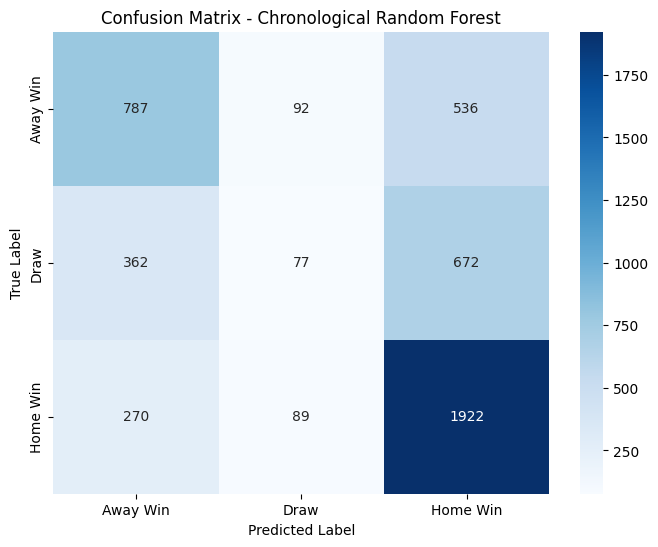

In [191]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Sort the original match data chronologically before creating the split.
# This prevents future matches from being used to predict earlier matches.
chronological_order = matches_ml['match_date'].sort_values().index
X = X.loc[chronological_order].reset_index(drop=True)
y = y[chronological_order.to_numpy()]

# Chronological 80/20 train-test split
split_index = int(len(X) * 0.80)
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y[:split_index]
y_test = y[split_index:]

# Leakage-free imputation: calculate means from training data only.
train_means = X_train.mean()
X_train = X_train.fillna(train_means)
X_test = X_test.fillna(train_means)

print("Chronological train/test split")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training period: {matches_ml.loc[chronological_order, 'match_date'].iloc[0]} to {matches_ml.loc[chronological_order, 'match_date'].iloc[split_index-1]}")
print(f"Testing period: {matches_ml.loc[chronological_order, 'match_date'].iloc[split_index]} to {matches_ml.loc[chronological_order, 'match_date'].iloc[-1]}")

# Train baseline Random Forest on the chronological training set
model_eval = RandomForestClassifier(n_estimators=100, random_state=42)
model_eval.fit(X_train, y_train)

y_pred = model_eval.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Chronological Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


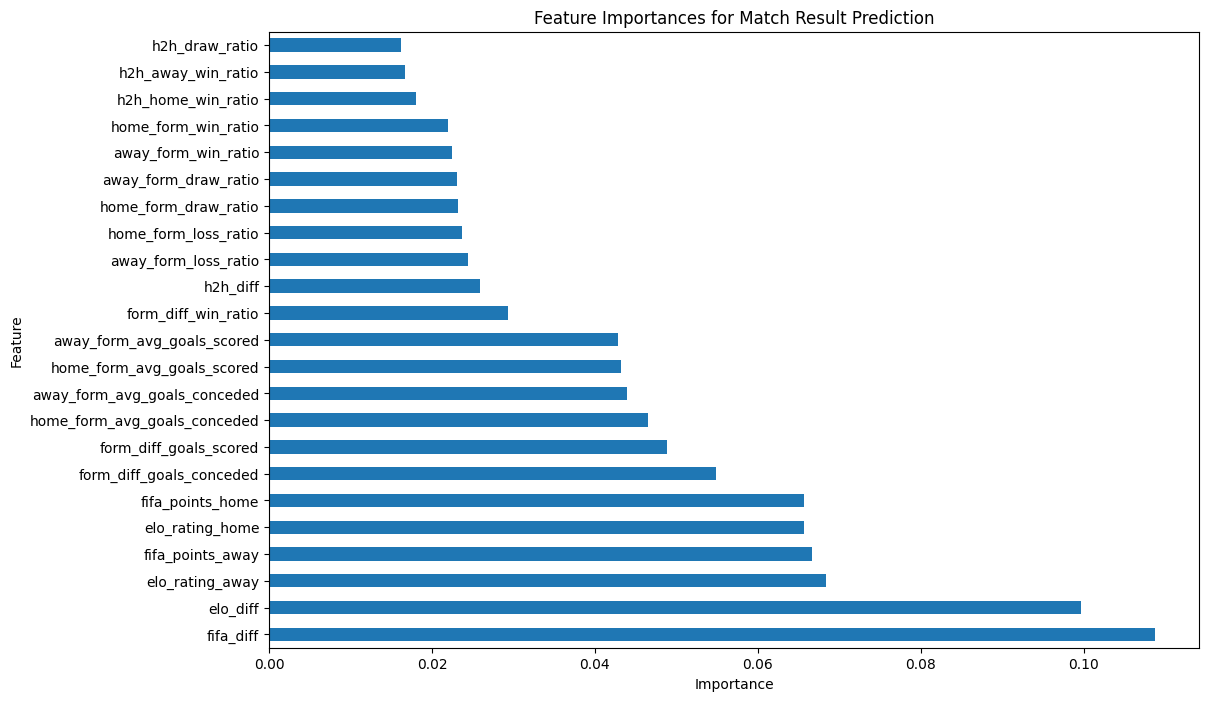

Top 10 features by importance:
fifa_diff                       0.108725
elo_diff                        0.099640
elo_rating_away                 0.068331
fifa_points_away                0.066692
elo_rating_home                 0.065651
fifa_points_home                0.065642
form_diff_goals_conceded        0.054811
form_diff_goals_scored          0.048881
home_form_avg_goals_conceded    0.046550
away_form_avg_goals_conceded    0.043953
dtype: float64


In [192]:

# Get feature importances
feature_importances = pd.Series(model_eval.feature_importances_, index=X.columns)

# Sort and plot feature importances
plt.figure(figsize=(12, 8))
feature_importances.sort_values(ascending=False).plot(kind='barh')
plt.title('Feature Importances for Match Result Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("Top 10 features by importance:")
print(feature_importances.nlargest(10))

Hyperparameter tuning is performed to identify the optimal Random Forest parameters and improve the model’s predictive performance using cross-validation.

In [193]:

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Random Forest
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Parameters to search
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized search
tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting RandomizedSearchCV...")

random_search.fit(X_train, y_train)

print("RandomizedSearchCV complete!")

print("\nBest parameters:")
print(random_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(round(random_search.best_score_, 4))

Starting RandomizedSearchCV...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
RandomizedSearchCV complete!

Best parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}

Best cross-validation Macro F1:
0.4875


In [194]:
# Best model
best_rf_model = random_search.best_estimator_

# Predictions
y_pred_tuned = best_rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_tuned)

print("\nTest Accuracy:", round(accuracy, 4))

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=le.classes_ # Changed from best_rf_model.classes_ to le.classes_
    )
)



Test Accuracy: 0.5534

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.54      0.60      0.57      1415
        Draw       0.28      0.27      0.27      1111
    Home Win       0.70      0.67      0.68      2281

    accuracy                           0.55      4807
   macro avg       0.51      0.51      0.51      4807
weighted avg       0.55      0.55      0.55      4807



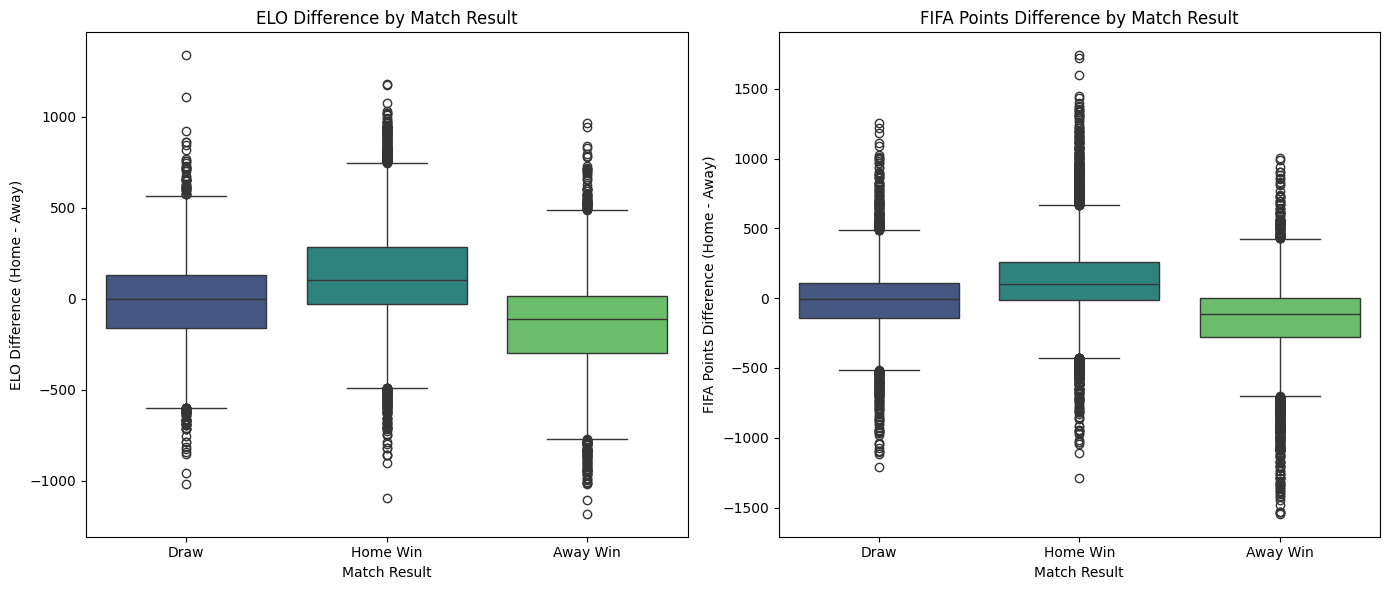

In [195]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='match_result', y='elo_diff', data=matches_ml, palette='viridis', hue='match_result', legend=False)
plt.title('ELO Difference by Match Result')
plt.xlabel('Match Result')
plt.ylabel('ELO Difference (Home - Away)')

plt.subplot(1, 2, 2)
sns.boxplot(x='match_result', y='fifa_diff', data=matches_ml, palette='viridis', hue='match_result', legend=False)
plt.title('FIFA Points Difference by Match Result')
plt.xlabel('Match Result')
plt.ylabel('FIFA Points Difference (Home - Away)')

plt.tight_layout()
plt.show()

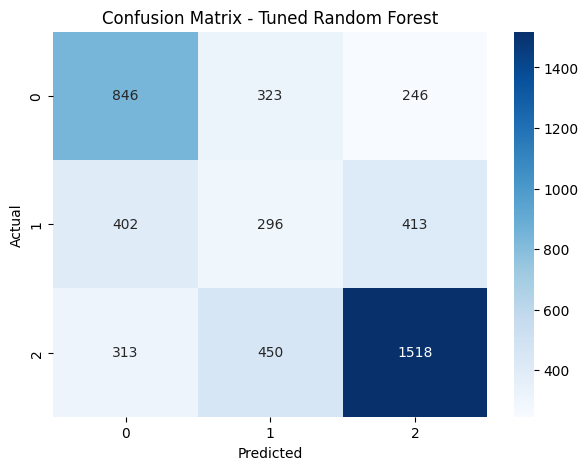

In [196]:
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_rf_model.classes_,
    yticklabels=best_rf_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [197]:
scoring='f1_macro'

In [198]:
class_weight='balanced'

## Logistic Regression Model

Logistic Regression is implemented as a second classification model to predict match outcomes and compare its performance with the Random Forest model.

Chronological Logistic Regression split:
Training samples: 19226
Testing samples: 4807
Training Logistic Regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression model trained!

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    Away Win       0.55      0.60      0.57      1415
        Draw       0.00      0.00      0.00      1111
    Home Win       0.60      0.86      0.71      2281

    accuracy                           0.59      4807
   macro avg       0.38      0.49      0.43      4807
weighted avg       0.45      0.59      0.51      4807



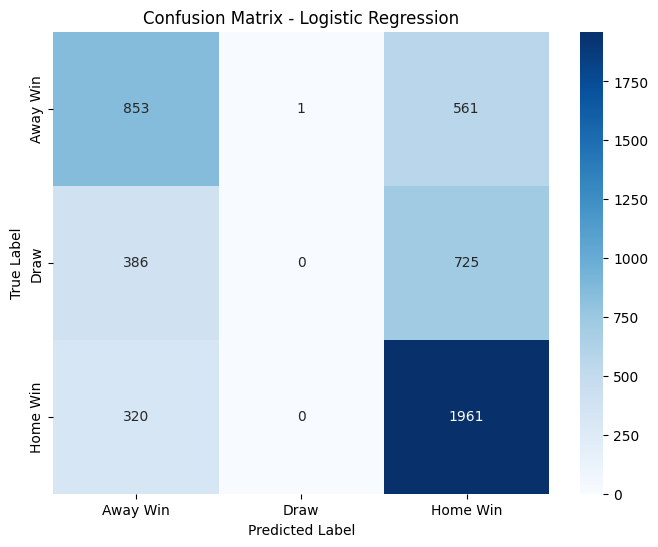

In [199]:
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Define features (X) and target (y)
# Drop non-feature and target columns, similar to RandomForest
columns_to_drop = [
    'match_date', 'home_team', 'away_team', 'home_goals', 'away_goals',
    'tournament', 'city', 'country', 'match_year', 'match_result'
]
X_lr = matches_ml.drop(columns=columns_to_drop)

# Encode the target variable 'match_result'
le_lr = LabelEncoder()
y_lr = le_lr.fit_transform(matches_ml['match_result'])

# Ensure all features in X are numerical by dropping any remaining non-numeric columns
X_lr = X_lr.select_dtypes(include=['number'])

# Sort chronologically and create an 80/20 time-based split
chronological_order_lr = matches_ml['match_date'].sort_values().index
X_lr = X_lr.loc[chronological_order_lr].reset_index(drop=True)
y_lr = y_lr[chronological_order_lr.to_numpy()]

split_index_lr = int(len(X_lr) * 0.80)
X_train_lr = X_lr.iloc[:split_index_lr].copy()
X_test_lr = X_lr.iloc[split_index_lr:].copy()
y_train_lr = y_lr[:split_index_lr]
y_test_lr = y_lr[split_index_lr:]

# Leakage-free imputation: means are learned from the training set only.
train_means_lr = X_train_lr.mean()
X_train_lr = X_train_lr.fillna(train_means_lr)
X_test_lr = X_test_lr.fillna(train_means_lr)

print("Chronological Logistic Regression split:")
print(f"Training samples: {len(X_train_lr)}")
print(f"Testing samples: {len(X_test_lr)}")

# Initialize and train the Logistic Regression model
# Using 'liblinear' solver for multi_class='ovr' or 'auto' (good for small datasets)
# 'C' is the inverse of regularization strength, smaller values specify stronger regularization.
log_reg_model = LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42, max_iter=1000)

print("Training Logistic Regression model...")
log_reg_model.fit(X_train_lr, y_train_lr)
print("Logistic Regression model trained!")

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test_lr)

# Generate and print the classification report
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test_lr, y_pred_lr, target_names=le_lr.classes_))

# Generate and plot the confusion matrix
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_lr.classes_, yticklabels=le_lr.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## XGBoost Model
XGBoost is implemented as another classification model to predict match outcomes and compare its performance with the Random Forest and Logistic Regression models.

Chronological XGBoost split:
Training samples: 19226
Testing samples: 4807
Training XGBoost model...
XGBoost model trained!

Classification Report (XGBoost):
              precision    recall  f1-score   support

    Away Win       0.56      0.52      0.54      1415
        Draw       0.27      0.12      0.17      1111
    Home Win       0.61      0.80      0.69      2281

    accuracy                           0.56      4807
   macro avg       0.48      0.48      0.47      4807
weighted avg       0.52      0.56      0.53      4807



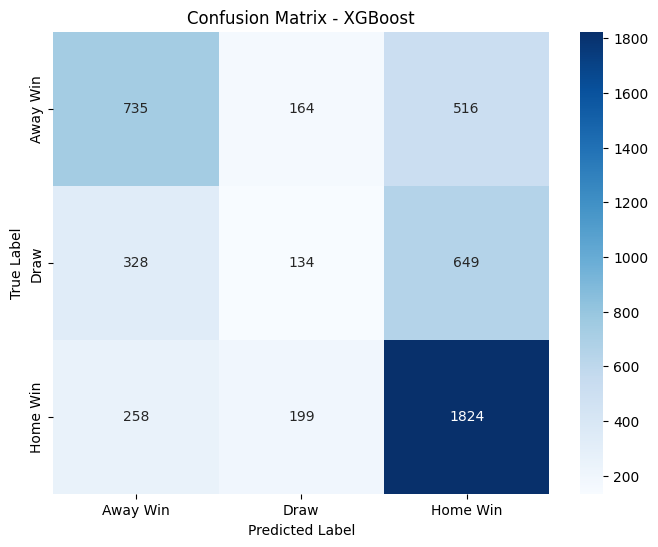

In [200]:
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define features (X) and target (y)
# Drop non-feature and target columns, similar to previous models
columns_to_drop = [
    'match_date', 'home_team', 'away_team', 'home_goals', 'away_goals',
    'tournament', 'city', 'country', 'match_year', 'match_result'
]
X_xgb = matches_ml.drop(columns=columns_to_drop)

# Encode the target variable 'match_result'
le_xgb = LabelEncoder()
y_xgb = le_xgb.fit_transform(matches_ml['match_result'])

# Ensure all features in X are numerical by dropping any remaining non-numeric columns
X_xgb = X_xgb.select_dtypes(include=['number'])

# Sort chronologically and create an 80/20 time-based split
chronological_order_xgb = matches_ml['match_date'].sort_values().index
X_xgb = X_xgb.loc[chronological_order_xgb].reset_index(drop=True)
y_xgb = y_xgb[chronological_order_xgb.to_numpy()]

split_index_xgb = int(len(X_xgb) * 0.80)
X_train_xgb = X_xgb.iloc[:split_index_xgb].copy()
X_test_xgb = X_xgb.iloc[split_index_xgb:].copy()
y_train_xgb = y_xgb[:split_index_xgb]
y_test_xgb = y_xgb[split_index_xgb:]

# Leakage-free imputation: means are learned from the training set only.
train_means_xgb = X_train_xgb.mean()
X_train_xgb = X_train_xgb.fillna(train_means_xgb)
X_test_xgb = X_test_xgb.fillna(train_means_xgb)

print("Chronological XGBoost split:")
print(f"Training samples: {len(X_train_xgb)}")
print(f"Testing samples: {len(X_test_xgb)}")

# Initialize and train the XGBoost model
# Using 'multi:softprob' for multi-class classification and 'mlogloss' as evaluation metric
# 'use_label_encoder=False' to avoid a future deprecation warning
xgb_model = XGBClassifier(
    objective='multi:softmax', # For multi-class classification
    num_class=len(le_xgb.classes_), # Number of classes
    eval_metric='mlogloss', # Evaluation metric for multi-class classification
    random_state=42,
    n_estimators=100
)

print("Training XGBoost model...")
xgb_model.fit(X_train_xgb, y_train_xgb)
print("XGBoost model trained!")

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Generate and print the classification report
print("\nClassification Report (XGBoost):")
print(classification_report(y_test_xgb, y_pred_xgb, target_names=le_xgb.classes_))

# Generate and plot the confusion matrix
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_xgb.classes_, yticklabels=le_xgb.classes_)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Hyperparameter Tuning for XGBoost Model

In [201]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the XGBoost classifier with balanced class weights (if applicable) and other base parameters
xgb_tuned = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le_xgb.classes_),
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False # To avoid a future deprecation warning
)

# Define the parameter distribution for RandomizedSearchCV
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

# Randomized search for XGBoost
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_dist_xgb,
    n_iter=20, # Number of parameter settings that are sampled. Increase for more exhaustive search.
    cv=TimeSeriesSplit(n_splits=3), # Time-aware cross-validation
    scoring='f1_macro', # Use f1_macro for multi-class classification, especially with imbalanced classes
    n_jobs=-1, # Use all available cores
    random_state=42,
    verbose=1
)

print("Starting RandomizedSearchCV for XGBoost...")
random_search_xgb.fit(X_train_xgb, y_train_xgb)
print("RandomizedSearchCV for XGBoost complete!")

print("\nBest parameters for XGBoost:")
print(random_search_xgb.best_params_)

print("\nBest cross-validation Macro F1 for XGBoost:")
print(round(random_search_xgb.best_score_, 4))

Starting RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:23:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV for XGBoost complete!

Best parameters for XGBoost:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}

Best cross-validation Macro F1 for XGBoost:
0.4599



Test Accuracy (Tuned XGBoost): 0.5600

Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

    Away Win       0.54      0.52      0.53      1415
        Draw       0.29      0.14      0.19      1111
    Home Win       0.62      0.79      0.69      2281

    accuracy                           0.56      4807
   macro avg       0.48      0.48      0.47      4807
weighted avg       0.52      0.56      0.53      4807



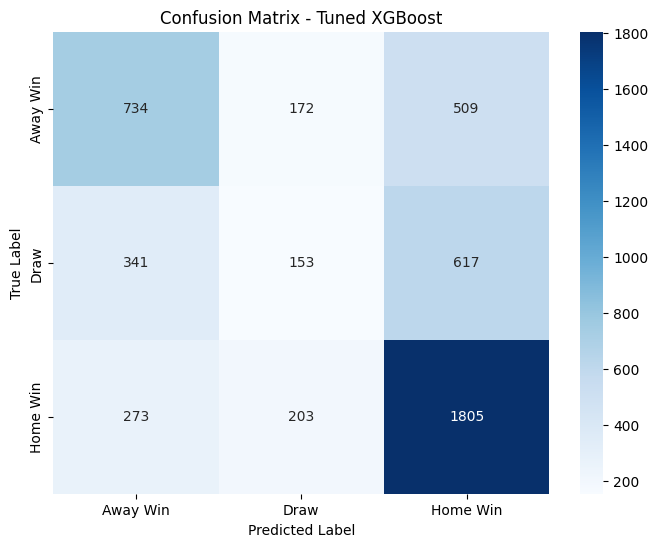

In [202]:
# Get the best XGBoost model
best_xgb_model = random_search_xgb.best_estimator_

# Make predictions on the test set using the tuned model
y_pred_tuned_xgb = best_xgb_model.predict(X_test_xgb)

# Evaluate the tuned XGBoost model
accuracy_tuned_xgb = accuracy_score(y_test_xgb, y_pred_tuned_xgb)
print(f"\nTest Accuracy (Tuned XGBoost): {accuracy_tuned_xgb:.4f}")

print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test_xgb, y_pred_tuned_xgb, target_names=le_xgb.classes_))

# Generate and plot the confusion matrix for the tuned XGBoost model
cm_tuned_xgb = confusion_matrix(y_test_xgb, y_pred_tuned_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_xgb.classes_, yticklabels=le_xgb.classes_)
plt.title('Confusion Matrix - Tuned XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [203]:
matches_ml.columns

Index(['match_date', 'home_team', 'away_team', 'home_goals', 'away_goals',
       'tournament', 'city', 'country', 'neutral_venue', 'match_year',
       'match_result', 'fifa_points_home', 'fifa_points_away',
       'elo_rating_home', 'elo_rating_away', 'fifa_diff', 'elo_diff',
       'home_form_avg_goals_scored', 'home_form_avg_goals_conceded',
       'home_form_win_ratio', 'home_form_draw_ratio', 'home_form_loss_ratio',
       'away_form_avg_goals_scored', 'away_form_avg_goals_conceded',
       'away_form_win_ratio', 'away_form_draw_ratio', 'away_form_loss_ratio',
       'h2h_home_win_ratio', 'h2h_draw_ratio', 'h2h_away_win_ratio',
       'form_diff_goals_scored', 'form_diff_goals_conceded',
       'form_diff_win_ratio', 'h2h_diff', 'home_confederation',
       'away_confederation'],
      dtype='object')

In [204]:
from collections import defaultdict, deque

# ============================================================
# Neutral-venue feature construction (NO H2H)
# ============================================================
# Team A / Team B is only an ordering convention. It does NOT imply home/away.
# We randomly swap the two teams and also swap the target so the model cannot
# learn the arbitrary fixture ordering as a home-field effect.

df_neutral = matches_ml.copy().sort_values('match_date').reset_index(drop=True)

df_neutral['match_date'] = pd.to_datetime(df_neutral['match_date'])

N_RECENT = 5
team_history = defaultdict(lambda: deque(maxlen=N_RECENT))
neutral_rows = []

for _, row in df_neutral.iterrows():
    home = row['home_team']
    away = row['away_team']

    def get_form_from_history(team):
        hist = team_history[team]
        if not hist:
            return {
                'avg_goals_scored': 0.0,
                'avg_goals_conceded': 0.0,
                'win_ratio': 0.0
            }
        gs = [x['goals_scored'] for x in hist]
        gc = [x['goals_conceded'] for x in hist]
        wins = sum(x['result'] == 'W' for x in hist)
        return {
            'avg_goals_scored': float(np.mean(gs)),
            'avg_goals_conceded': float(np.mean(gc)),
            'win_ratio': wins / len(hist)
        }

    home_form = get_form_from_history(home)
    away_form = get_form_from_history(away)

    # 0 = keep original home/away order as Team A/B; 1 = swap them.
    swap = int(np.random.RandomState(42 + len(neutral_rows)).randint(0, 2))

    if swap == 0:
        team_a, team_b = home, away
        fifa_diff = row['fifa_diff']
        elo_diff = row['elo_diff']
        form_scored = home_form['avg_goals_scored'] - away_form['avg_goals_scored']
        form_conceded = home_form['avg_goals_conceded'] - away_form['avg_goals_conceded']
        form_win = home_form['win_ratio'] - away_form['win_ratio']
        if row['match_result'] == 'Home Win':
            target = 'Team A Win'
        elif row['match_result'] == 'Away Win':
            target = 'Team B Win'
        else:
            target = 'Draw'
    else:
        team_a, team_b = away, home
        fifa_diff = -row['fifa_diff']
        elo_diff = -row['elo_diff']
        form_scored = away_form['avg_goals_scored'] - home_form['avg_goals_scored']
        form_conceded = away_form['avg_goals_conceded'] - home_form['avg_goals_conceded']
        form_win = away_form['win_ratio'] - home_form['win_ratio']
        if row['match_result'] == 'Home Win':
            target = 'Team B Win'
        elif row['match_result'] == 'Away Win':
            target = 'Team A Win'
        else:
            target = 'Draw'

    neutral_rows.append({
        'match_date': row['match_date'],
        'team_A': team_a,
        'team_B': team_b,
        'fifa_diff': fifa_diff,
        'elo_diff': elo_diff,
        'form_diff_goals_scored': form_scored,
        'form_diff_goals_conceded': form_conceded,
        'form_diff_win_ratio': form_win,
        'match_result': target
    })

    # Update history only AFTER current-match features/target are created.
    hg, ag = row['home_goals'], row['away_goals']
    if hg > ag:
        hr, ar = 'W', 'L'
    elif hg < ag:
        hr, ar = 'L', 'W'
    else:
        hr, ar = 'D', 'D'

    team_history[home].append({'goals_scored': hg, 'goals_conceded': ag, 'result': hr})
    team_history[away].append({'goals_scored': ag, 'goals_conceded': hg, 'result': ar})

neutral_model_df = pd.DataFrame(neutral_rows).sort_values('match_date').reset_index(drop=True)

final_features = [
    'elo_diff',
    'fifa_diff',
    'form_diff_goals_conceded',
    'form_diff_goals_scored',
    'form_diff_win_ratio'
]

print('Neutral model features:', final_features)
print('\nTarget distribution:')
print(neutral_model_df['match_result'].value_counts())

display(neutral_model_df.head())

Neutral model features: ['elo_diff', 'fifa_diff', 'form_diff_goals_conceded', 'form_diff_goals_scored', 'form_diff_win_ratio']

Target distribution:
match_result
Team B Win    9255
Team A Win    9170
Draw          5608
Name: count, dtype: int64


,match_date,team_A,team_B,fifa_diff,elo_diff,form_diff_goals_scored,form_diff_goals_conceded,form_diff_win_ratio,match_result
0,2000-01-02,zambia,senegal,131.0,185.0,0.0,0.0,0.0,Draw
1,2000-01-02,egypt,burkina faso,100.0,155.0,0.0,0.0,0.0,Team A Win
2,2000-01-02,british virgin islands,saint lucia,-421.0,0.0,0.0,0.0,0.0,Team B Win
3,2000-01-03,lesotho,zambia,-401.0,-452.0,-2.0,-2.0,0.0,Team B Win
4,2000-01-04,barbados,aruba,278.0,22.0,0.0,0.0,0.0,Team A Win


In [205]:
# Model A: with H2H
features_with_h2h = [
    'elo_diff',
    'fifa_diff',
    'form_diff_goals_conceded',
    'form_diff_goals_scored',
    'form_diff_win_ratio',
    'h2h_diff'
]

# Model B: without H2H
features_without_h2h = [
    'elo_diff',
    'fifa_diff',
    'form_diff_goals_conceded',
    'form_diff_goals_scored',
    'form_diff_win_ratio'
]

target = 'match_result'

print("With H2H:", features_with_h2h)
print("Without H2H:", features_without_h2h)

With H2H: ['elo_diff', 'fifa_diff', 'form_diff_goals_conceded', 'form_diff_goals_scored', 'form_diff_win_ratio', 'h2h_diff']
Without H2H: ['elo_diff', 'fifa_diff', 'form_diff_goals_conceded', 'form_diff_goals_scored', 'form_diff_win_ratio']


In [206]:
from sklearn.preprocessing import LabelEncoder

# Target encoding
le_compare = LabelEncoder()

y_compare = le_compare.fit_transform(matches_ml[target])

# Sort all matches chronologically first
chronological_order_compare = matches_ml['match_date'].sort_values().index

# Model A
X_h2h = matches_ml.loc[chronological_order_compare, features_with_h2h].reset_index(drop=True)

# Model B
X_no_h2h = matches_ml.loc[chronological_order_compare, features_without_h2h].reset_index(drop=True)

y_compare = y_compare[chronological_order_compare.to_numpy()]


In [207]:

# Chronological 80/20 split for a fair H2H vs no-H2H comparison
split_index_compare = int(len(X_h2h) * 0.80)

X_train_h2h = X_h2h.iloc[:split_index_compare].copy()
X_test_h2h = X_h2h.iloc[split_index_compare:].copy()

X_train_no_h2h = X_no_h2h.iloc[:split_index_compare].copy()
X_test_no_h2h = X_no_h2h.iloc[split_index_compare:].copy()

y_train = y_compare[:split_index_compare]
y_test = y_compare[split_index_compare:]

# Leakage-free imputation: each model learns means from its training data only.
train_means_h2h = X_train_h2h.mean()
X_train_h2h = X_train_h2h.fillna(train_means_h2h)
X_test_h2h = X_test_h2h.fillna(train_means_h2h)

train_means_no_h2h = X_train_no_h2h.mean()
X_train_no_h2h = X_train_no_h2h.fillna(train_means_no_h2h)
X_test_no_h2h = X_test_no_h2h.fillna(train_means_no_h2h)

print("Chronological H2H comparison split:")
print(f"Training samples: {len(X_train_h2h)}")
print(f"Testing samples: {len(X_test_h2h)}")


Chronological H2H comparison split:
Training samples: 19226
Testing samples: 4807


In [208]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf_h2h = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_h2h.fit(X_train_h2h, y_train)

y_pred_h2h = rf_h2h.predict(X_test_h2h)

acc_h2h = accuracy_score(y_test, y_pred_h2h)
f1_h2h = f1_score(y_test, y_pred_h2h, average='macro')

print("===== RANDOM FOREST WITH H2H =====")
print("Accuracy:", round(acc_h2h, 4))
print("Macro F1:", round(f1_h2h, 4))

print(classification_report(
    y_test,
    y_pred_h2h,
    target_names=le_compare.classes_
))

===== RANDOM FOREST WITH H2H =====
Accuracy: 0.5733
Macro F1: 0.4596
              precision    recall  f1-score   support

    Away Win       0.57      0.54      0.56      1415
        Draw       0.26      0.08      0.12      1111
    Home Win       0.61      0.84      0.70      2281

    accuracy                           0.57      4807
   macro avg       0.48      0.48      0.46      4807
weighted avg       0.52      0.57      0.52      4807



In [209]:
rf_no_h2h = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_no_h2h.fit(X_train_no_h2h, y_train)

y_pred_no_h2h = rf_no_h2h.predict(X_test_no_h2h)

acc_no_h2h = accuracy_score(y_test, y_pred_no_h2h)
f1_no_h2h = f1_score(y_test, y_pred_no_h2h, average='macro')

print("===== RANDOM FOREST WITHOUT H2H =====")
print("Accuracy:", round(acc_no_h2h, 4))
print("Macro F1:", round(f1_no_h2h, 4))

print(classification_report(
    y_test,
    y_pred_no_h2h,
    target_names=le_compare.classes_
))

===== RANDOM FOREST WITHOUT H2H =====
Accuracy: 0.5683
Macro F1: 0.4671
              precision    recall  f1-score   support

    Away Win       0.57      0.52      0.55      1415
        Draw       0.30      0.11      0.16      1111
    Home Win       0.60      0.82      0.70      2281

    accuracy                           0.57      4807
   macro avg       0.49      0.48      0.47      4807
weighted avg       0.52      0.57      0.53      4807



In [210]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest + H2H',
        'Random Forest - H2H'
    ],
    'Accuracy': [
        acc_h2h,
        acc_no_h2h
    ],
    'Macro F1': [
        f1_h2h,
        f1_no_h2h
    ]
})

print(comparison)

                 Model  Accuracy  Macro F1
0  Random Forest + H2H  0.573331  0.459556
1  Random Forest - H2H  0.568338  0.467111


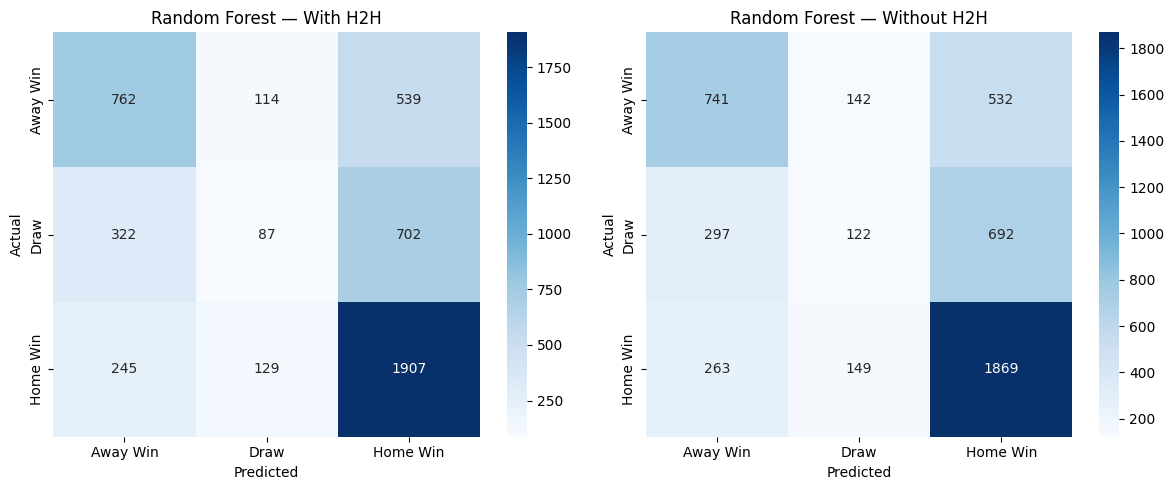

In [211]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_h2h = confusion_matrix(y_test, y_pred_h2h)
cm_no_h2h = confusion_matrix(y_test, y_pred_no_h2h)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_h2h,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_compare.classes_,
    yticklabels=le_compare.classes_,
    ax=axes[0]
)

axes[0].set_title("Random Forest — With H2H")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_no_h2h,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_compare.classes_,
    yticklabels=le_compare.classes_,
    ax=axes[1]
)

axes[1].set_title("Random Forest — Without H2H")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [212]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Starting Random Forest tuning...")

grid_search.fit(X_train_no_h2h, y_train)

print("Tuning complete!")
print("Best parameters:")
print(grid_search.best_params_)

print("Best CV Macro F1:",
      round(grid_search.best_score_, 4))

Starting Random Forest tuning...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tuning complete!
Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Macro F1: 0.4582


In [213]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_no_h2h)

from sklearn.metrics import accuracy_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred_tuned)
macro_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print("Tuned Random Forest Accuracy:", round(accuracy, 4))
print("Tuned Random Forest Macro F1:", round(macro_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=le_compare.classes_
))

Tuned Random Forest Accuracy: 0.5588
Tuned Random Forest Macro F1: 0.4672

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.55      0.51      0.53      1415
        Draw       0.29      0.13      0.18      1111
    Home Win       0.61      0.80      0.69      2281

    accuracy                           0.56      4807
   macro avg       0.48      0.48      0.47      4807
weighted avg       0.52      0.56      0.53      4807



In [214]:
import pandas as pd
import numpy as np

# Make sure match_date is datetime
matches_ml['match_date'] = pd.to_datetime(matches_ml['match_date'])

# Sort from oldest to newest
matches_ml = matches_ml.sort_values('match_date').reset_index(drop=True)

print(matches_ml[['match_date', 'match_result']].head())
print(matches_ml[['match_date', 'match_result']].tail())

  match_date match_result
0 2000-01-02         Draw
1 2000-01-02     Home Win
2 2000-01-02     Away Win
3 2000-01-03     Home Win
4 2000-01-04     Away Win
      match_date match_result
24028 2024-12-28     Away Win
24029 2024-12-29     Home Win
24030 2024-12-30     Home Win
24031 2024-12-31     Home Win
24032 2024-12-31     Away Win


## Final production pipeline — neutral World Cup representation

Team A and Team B are an ordering convention only. The model uses Team A minus Team B differences and a correctly swapped target, so the arbitrary listing order does not introduce home-field advantage. H2H is excluded from the production features. Missing values at inference use means learned from the training split only.


In [215]:

# FINAL PRODUCTION MODEL — NEUTRAL VENUE / TEAM A vs TEAM

final_features = [
    'elo_diff',
    'fifa_diff',
    'form_diff_goals_conceded',
    'form_diff_goals_scored',
    'form_diff_win_ratio'
]

target = 'match_result'

neutral_model_df = neutral_model_df.sort_values('match_date').reset_index(drop=True)
X = neutral_model_df[final_features].copy()
y = neutral_model_df[target].copy()
print('Final features:', final_features)
print('Shape:', X.shape)

Final features: ['elo_diff', 'fifa_diff', 'form_diff_goals_conceded', 'form_diff_goals_scored', 'form_diff_win_ratio']
Shape: (24033, 5)


In [216]:
from sklearn.preprocessing import LabelEncoder

le_final = LabelEncoder()
y_encoded = le_final.fit_transform(y)
print('Classes:', le_final.classes_)

Classes: ['Draw' 'Team A Win' 'Team B Win']


In [217]:
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y_encoded[:split_index]
y_test = y_encoded[split_index:]

# Leakage-free imputation: learn means from training data only.
train_means_final = X_train.mean()
X_train = X_train.fillna(train_means_final)
X_test = X_test.fillna(train_means_final)

print('Training matches:', len(X_train))
print('Testing matches:', len(X_test))
print('\nTraining period:')
print(neutral_model_df['match_date'].iloc[0], 'to', neutral_model_df['match_date'].iloc[split_index - 1])
print('\nTesting period:')
print(neutral_model_df['match_date'].iloc[split_index], 'to', neutral_model_df['match_date'].iloc[-1])

Training matches: 19226
Testing matches: 4807

Training period:
2000-01-02 00:00:00 to 2019-11-18 00:00:00

Testing period:
2019-11-18 00:00:00 to 2024-12-31 00:00:00


In [218]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print('Starting time-aware Random Forest tuning...')
grid_search.fit(X_train, y_train)

print('\nTuning complete!')
print('\nBest parameters:')
print(grid_search.best_params_)
print('\nBest CV Macro F1:', round(grid_search.best_score_, 4))

Starting time-aware Random Forest tuning...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Tuning complete!

Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best CV Macro F1: 0.4553


In [219]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

best_rf_time = grid_search.best_estimator_
y_pred = best_rf_time.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print('Time-Based Neutral Random Forest')
print('----------------------------------')
print('Accuracy:', round(accuracy, 4))
print('Macro F1:', round(macro_f1, 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le_final.classes_))

Time-Based Neutral Random Forest
----------------------------------
Accuracy: 0.5423
Macro F1: 0.4663

Classification Report:
              precision    recall  f1-score   support

        Draw       0.25      0.12      0.16      1110
  Team A Win       0.57      0.66      0.61      1811
  Team B Win       0.59      0.68      0.63      1886

    accuracy                           0.54      4807
   macro avg       0.47      0.49      0.47      4807
weighted avg       0.50      0.54      0.51      4807



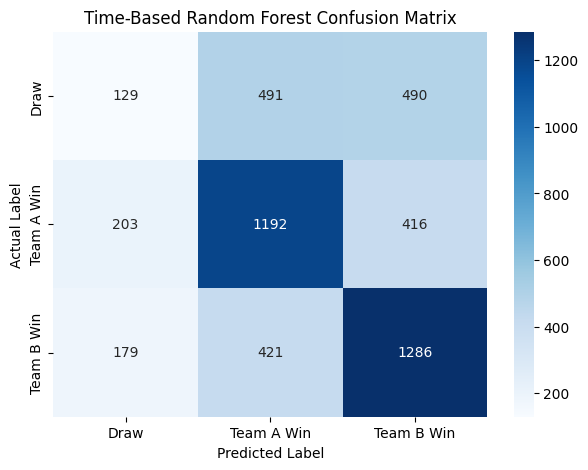

In [220]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_final.classes_,
    yticklabels=le_final.classes_
)

plt.title("Time-Based Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [221]:
importance = pd.DataFrame({
    'Feature': final_features,
    'Importance': best_rf_time.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

print(importance)

                    Feature  Importance
1                 fifa_diff    0.302862
0                  elo_diff    0.291676
2  form_diff_goals_conceded    0.162187
3    form_diff_goals_scored    0.153574
4       form_diff_win_ratio    0.089701


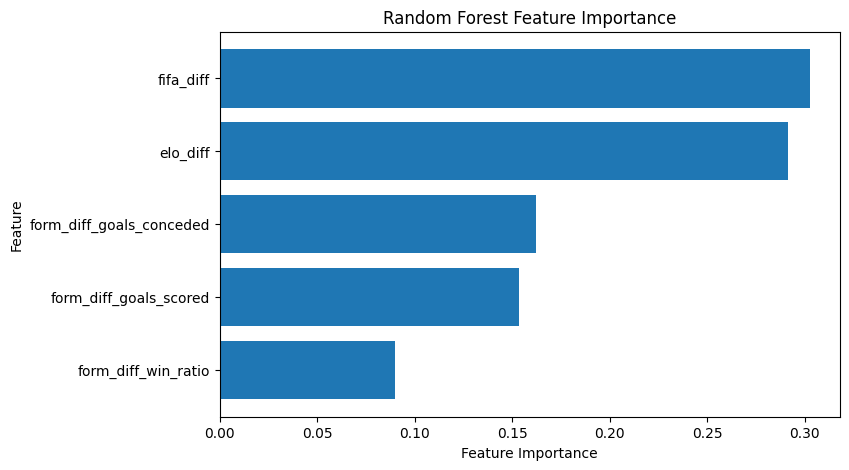

In [222]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [223]:
import shap

# Take at most 1000 test matches
X_shap = X_test.sample(
    min(1000, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(best_rf_time)

shap_values = explainer.shap_values(X_shap)

print("SHAP calculated!")
print("Shape:", np.array(shap_values).shape)

SHAP calculated!
Shape: (1000, 5, 3)


In [224]:
shap_array = np.array(shap_values)

mean_abs_shap = np.mean(
    np.abs(shap_array),
    axis=(0, 2)
)

shap_importance = pd.DataFrame({
    'Feature': X_shap.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values(
    'Mean |SHAP|',
    ascending=True
)

print(shap_importance)

                    Feature  Mean |SHAP|
4       form_diff_win_ratio     0.016012
3    form_diff_goals_scored     0.021698
2  form_diff_goals_conceded     0.035298
0                  elo_diff     0.064785
1                 fifa_diff     0.080798


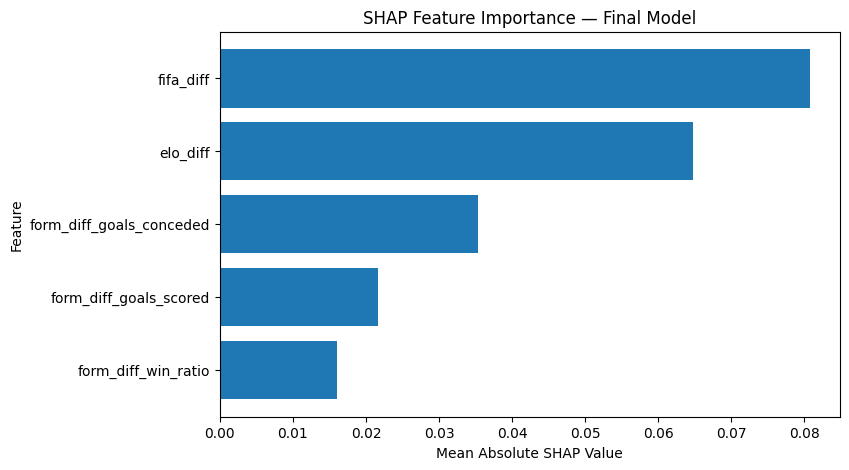

In [225]:
plt.figure(figsize=(8, 5))

plt.barh(
    shap_importance['Feature'],
    shap_importance['Mean |SHAP|']
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance — Final Model")

plt.show()


SHAP for: Draw


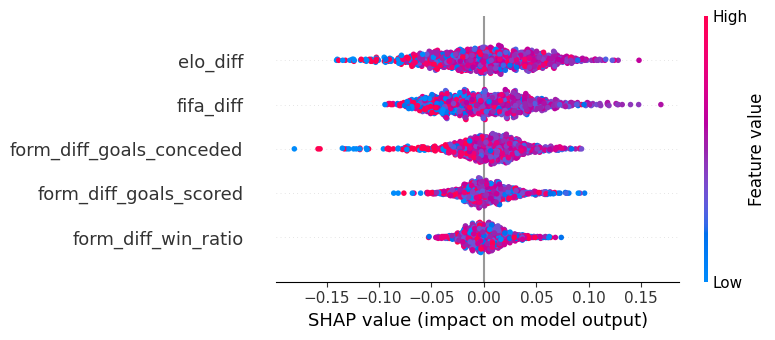


SHAP for: Team A Win


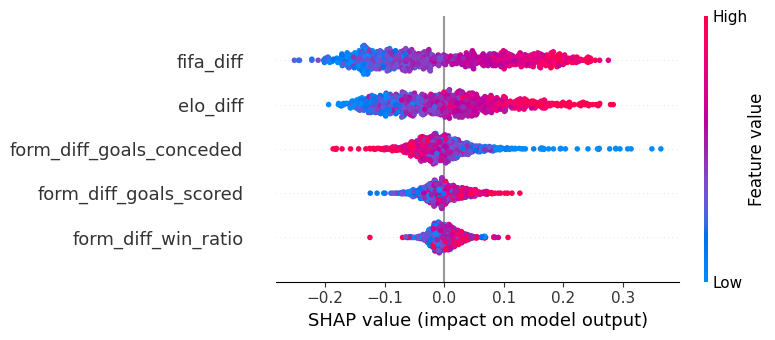


SHAP for: Team B Win


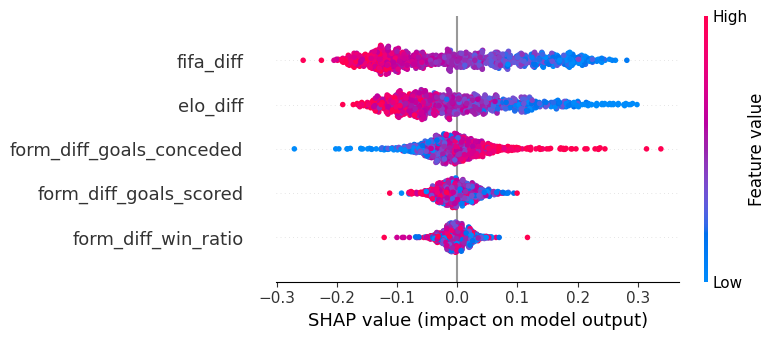

In [226]:
for class_index, class_name in enumerate(le_final.classes_):

    print("\nSHAP for:", class_name)

    shap.summary_plot(
        shap_array[:, :, class_index],
        X_shap,
        feature_names=X_shap.columns
    )

In [227]:
world_cup_2026_df = pd.read_excel('/content/World_Cup_2026_Fixtures_with_Elo_FIFA.xlsx')

# Canonical team names. These names are used consistently for training and inference.
world_cup_2026_df['team_A'] = world_cup_2026_df['Team A'].apply(robust_standardize)
world_cup_2026_df['team_B'] = world_cup_2026_df['Team B'].apply(robust_standardize)
world_cup_2026_df['match_date'] = pd.to_datetime(world_cup_2026_df['Date'])
world_cup_2026_df['match_year'] = world_cup_2026_df['match_date'].dt.year

world_cup_2026_df['fifa_points_A'] = world_cup_2026_df['Team A FIFA Points']
world_cup_2026_df['fifa_points_B'] = world_cup_2026_df['Team B FIFA Points']
world_cup_2026_df['elo_A'] = world_cup_2026_df['Team A Elo']
world_cup_2026_df['elo_B'] = world_cup_2026_df['Team B Elo']

# 2026 rating fallback: use historical confederation medians, then overall historical median.
for col, team_col, source_col in [
    ('fifa_points_A', 'team_A', 'fifa_points_home'),
    ('fifa_points_B', 'team_B', 'fifa_points_away'),
    ('elo_A', 'team_A', 'elo_rating_home'),
    ('elo_B', 'team_B', 'elo_rating_away')
]:
    missing = world_cup_2026_df[col].isna()
    if missing.any():
        conf_map = matches_ml.groupby(
            matches_ml[team_col.replace('team_', 'home_') if team_col == 'team_A' else 'away_confederation']
        )[source_col].median()

    # Simpler and stable fallback using current confederation labels.
    conf_column = 'home_confederation' if team_col == 'team_A' else 'away_confederation'
    world_cup_2026_df[conf_column] = world_cup_2026_df[team_col].map(CONFEDERATION_MAP)
    conf_map = matches_ml.groupby(conf_column)[source_col].median()
    overall_median = matches_ml[source_col].median()
    world_cup_2026_df[col] = world_cup_2026_df.apply(
        lambda r: r[col] if pd.notna(r[col]) else conf_map.get(r[conf_column], overall_median),
        axis=1
    )

world_cup_2026_df['fifa_diff'] = world_cup_2026_df['fifa_points_A'] - world_cup_2026_df['fifa_points_B']
world_cup_2026_df['elo_diff'] = world_cup_2026_df['elo_A'] - world_cup_2026_df['elo_B']

display(world_cup_2026_df.head())

,Match No.,Date,Stage,Group,Team A,Team A Elo,Team A FIFA Points,Team B,Team B Elo,Team B FIFA Points,...,match_date,match_year,fifa_points_A,fifa_points_B,elo_A,elo_B,home_confederation,away_confederation,fifa_diff,elo_diff
0,1,2026-06-11,Group Stage,A,Mexico,1835,1754.30,South Africa,1531,1451.24,...,2026-06-11,2026,1754.30,1451.24,1835,1531,CONCACAF,CAF,303.06,304
1,2,2026-06-11,Group Stage,A,Korea Republic,1784,1558.72,Czechia,1731,1467.26,...,2026-06-11,2026,1558.72,1467.26,1784,1731,AFC,UEFA,91.46,53
2,3,2026-06-18,Group Stage,A,Czechia,1731,1467.26,South Africa,1531,1451.24,...,2026-06-18,2026,1467.26,1451.24,1731,1531,UEFA,CAF,16.02,200
3,4,2026-06-18,Group Stage,A,Mexico,1835,1754.30,Korea Republic,1784,1558.72,...,2026-06-18,2026,1754.30,1558.72,1835,1784,CONCACAF,AFC,195.58,51
4,5,2026-06-24,Group Stage,A,Czechia,1731,1467.26,Mexico,1835,1754.30,...,2026-06-24,2026,1467.26,1754.30,1731,1835,UEFA,CONCACAF,-287.04,-104


### Preparing 2026 World Cup Fixtures for Prediction

In [228]:
# The prediction features are explicitly Team A minus Team B.
# Team A is NOT treated as the home team.

### Generating Recent Form for 2026 Team A / Team B Fixtures

In [229]:
# Recent form is calculated from matches strictly before each 2026 fixture.
# No H2H features are used in the production model.

for col in [
    'form_A_goals_scored', 'form_A_goals_conceded', 'form_A_win_ratio',
    'form_B_goals_scored', 'form_B_goals_conceded', 'form_B_win_ratio'
]:
    world_cup_2026_df[col] = 0.0

historical_matches_df = matches_ml.copy().sort_values('match_date')

for i, row in world_cup_2026_df.iterrows():
    team_A = row['team_A']
    team_B = row['team_B']
    match_date = row['match_date']

    history_before_match = historical_matches_df[
        historical_matches_df['match_date'] < match_date
    ]

    form_A = get_team_recent_form(team_A, match_date, history_before_match, window=5)
    form_B = get_team_recent_form(team_B, match_date, history_before_match, window=5)

    world_cup_2026_df.loc[i, 'form_A_goals_scored'] = form_A['avg_goals_scored']
    world_cup_2026_df.loc[i, 'form_A_goals_conceded'] = form_A['avg_goals_conceded']
    world_cup_2026_df.loc[i, 'form_A_win_ratio'] = form_A['win_ratio']

    world_cup_2026_df.loc[i, 'form_B_goals_scored'] = form_B['avg_goals_scored']
    world_cup_2026_df.loc[i, 'form_B_goals_conceded'] = form_B['avg_goals_conceded']
    world_cup_2026_df.loc[i, 'form_B_win_ratio'] = form_B['win_ratio']

world_cup_2026_df['form_diff_goals_scored'] = world_cup_2026_df['form_A_goals_scored'] - world_cup_2026_df['form_B_goals_scored']
world_cup_2026_df['form_diff_goals_conceded'] = world_cup_2026_df['form_A_goals_conceded'] - world_cup_2026_df['form_B_goals_conceded']
world_cup_2026_df['form_diff_win_ratio'] = world_cup_2026_df['form_A_win_ratio'] - world_cup_2026_df['form_B_win_ratio']

display(world_cup_2026_df.head())

,Match No.,Date,Stage,Group,Team A,Team A Elo,Team A FIFA Points,Team B,Team B Elo,Team B FIFA Points,...,elo_diff,form_A_goals_scored,form_A_goals_conceded,form_A_win_ratio,form_B_goals_scored,form_B_goals_conceded,form_B_win_ratio,form_diff_goals_scored,form_diff_goals_conceded,form_diff_win_ratio
0,1,2026-06-11,Group Stage,A,Mexico,1835,1754.30,South Africa,1531,1451.24,...,304,1.6,1.0,0.4,2.8,0.4,0.8,-1.2,0.6,-0.4
1,2,2026-06-11,Group Stage,A,Korea Republic,1784,1558.72,Czechia,1731,1467.26,...,53,2.0,0.8,0.8,1.6,0.8,0.6,0.4,0.0,0.2
2,3,2026-06-18,Group Stage,A,Czechia,1731,1467.26,South Africa,1531,1451.24,...,200,1.6,0.8,0.6,2.8,0.4,0.8,-1.2,0.4,-0.2
3,4,2026-06-18,Group Stage,A,Mexico,1835,1754.30,Korea Republic,1784,1558.72,...,51,1.6,1.0,0.4,2.0,0.8,0.8,-0.4,0.2,-0.4
4,5,2026-06-24,Group Stage,A,Czechia,1731,1467.26,Mexico,1835,1754.30,...,-104,1.6,0.8,0.6,1.6,1.0,0.4,0.0,-0.2,0.2


:### Predicting World Cup 2026 Match Results



In [230]:
# Final inference matrix: strictly Team A vs Team B, never home vs away.
X_2026_predict = world_cup_2026_df[final_features].copy()

# Use ONLY training-set means learned during the chronological split.
X_2026_predict = X_2026_predict.fillna(train_means_final)

print('Missing values after training-mean imputation:', int(X_2026_predict.isna().sum().sum()))
print('Features for prediction:')
display(X_2026_predict.head())

predictions_encoded = best_rf_time.predict(X_2026_predict)
predictions = le_final.inverse_transform(predictions_encoded)
world_cup_2026_df['Predicted Result'] = predictions

print('\nWorld Cup 2026 Match Predictions:')
display(world_cup_2026_df[[
    'match_date', 'team_A', 'team_B', 'Stage', 'Predicted Result',
    'fifa_points_A', 'fifa_points_B', 'elo_A', 'elo_B',
    'fifa_diff', 'elo_diff',
    'form_diff_goals_scored', 'form_diff_goals_conceded', 'form_diff_win_ratio'
]].head(10))

Missing values after training-mean imputation: 0
Features for prediction:


,elo_diff,fifa_diff,form_diff_goals_conceded,form_diff_goals_scored,form_diff_win_ratio
0,304,303.06,0.6,-1.2,-0.4
1,53,91.46,0.0,0.4,0.2
2,200,16.02,0.4,-1.2,-0.2
3,51,195.58,0.2,-0.4,-0.4
4,-104,-287.04,-0.2,0.0,0.2



World Cup 2026 Match Predictions:


,match_date,team_A,team_B,Stage,Predicted Result,fifa_points_A,fifa_points_B,elo_A,elo_B,fifa_diff,elo_diff,form_diff_goals_scored,form_diff_goals_conceded,form_diff_win_ratio
0,2026-06-11,mexico,south africa,Group Stage,Team A Win,1754.30,1451.24,1835,1531,303.06,304,-1.2,0.6,-0.4
1,2026-06-11,south korea,czech republic,Group Stage,Team B Win,1558.72,1467.26,1784,1731,91.46,53,0.4,0.0,0.2
2,2026-06-18,czech republic,south africa,Group Stage,Team B Win,1467.26,1451.24,1731,1531,16.02,200,-1.2,0.4,-0.2
3,2026-06-18,mexico,south korea,Group Stage,Team A Win,1754.30,1558.72,1835,1784,195.58,51,-0.4,0.2,-0.4
4,2026-06-24,czech republic,mexico,Group Stage,Team B Win,1467.26,1754.30,1731,1835,-287.04,-104,0.0,-0.2,0.2
5,2026-06-24,south africa,south korea,Group Stage,Team B Win,1451.24,1558.72,1531,1784,-107.48,-253,0.8,-0.4,0.0
6,2026-06-12,canada,bosnia and herzegovina,Group Stage,Team A Win,1571.34,1408.93,1802,1571,162.41,231,0.8,-1.8,0.6
7,2026-06-13,qatar,switzerland,Group Stage,Draw,1411.06,1710.88,1427,1897,-299.82,-470,0.0,-0.6,0.2
8,2026-06-18,switzerland,bosnia and herzegovina,Group Stage,Team A Win,1710.88,1408.93,1897,1571,301.95,326,0.8,0.0,0.0
9,2026-06-18,canada,qatar,Group Stage,Team A Win,1571.34,1411.06,1802,1427,160.28,375,0.0,-1.2,0.4


In [231]:
# Sanity check: the model output is expressed from Team A's perspective.
print(world_cup_2026_df['Predicted Result'].value_counts())

Predicted Result
Team A Win    55
Team B Win    36
Draw          13
Name: count, dtype: int64


In [232]:
actual_results = pd.read_excel('/content/world_cup_2026_actual_results.xlsx')
actual_results.head()

,Match ID,Date,Stage,Team A,Team B,Team A Score (90 min/FT),Team B Score (90 min/FT),Actual Winner / Outcome,Result Type,90-Minute Result
0,1,2026-06-11,Group Stage,Mexico,South Africa,2,0,Mexico,Win,Team A Win
1,2,2026-06-12,Group Stage,Korea Republic,Czechia,2,1,Korea Republic,Win,Team A Win
2,3,2026-06-12,Group Stage,Canada,Bosnia and Herzegovina,1,1,Draw,Draw,Draw
3,4,2026-06-13,Group Stage,United States,Paraguay,4,1,United States,Win,Team A Win
4,5,2026-06-14,Group Stage,Haiti,Scotland,0,1,Scotland,Win,Team B Win


In [233]:


# World Cup prediction dataframe
predictions = world_cup_2026_df.copy()

print("Actual results:")
display(actual_results.head())

print("Predictions:")
display(predictions.head())

Actual results:


,Match ID,Date,Stage,Team A,Team B,Team A Score (90 min/FT),Team B Score (90 min/FT),Actual Winner / Outcome,Result Type,90-Minute Result
0,1,2026-06-11,Group Stage,Mexico,South Africa,2,0,Mexico,Win,Team A Win
1,2,2026-06-12,Group Stage,Korea Republic,Czechia,2,1,Korea Republic,Win,Team A Win
2,3,2026-06-12,Group Stage,Canada,Bosnia and Herzegovina,1,1,Draw,Draw,Draw
3,4,2026-06-13,Group Stage,United States,Paraguay,4,1,United States,Win,Team A Win
4,5,2026-06-14,Group Stage,Haiti,Scotland,0,1,Scotland,Win,Team B Win


Predictions:


,Match No.,Date,Stage,Group,Team A,Team A Elo,Team A FIFA Points,Team B,Team B Elo,Team B FIFA Points,...,form_A_goals_scored,form_A_goals_conceded,form_A_win_ratio,form_B_goals_scored,form_B_goals_conceded,form_B_win_ratio,form_diff_goals_scored,form_diff_goals_conceded,form_diff_win_ratio,Predicted Result
0,1,2026-06-11,Group Stage,A,Mexico,1835,1754.30,South Africa,1531,1451.24,...,1.6,1.0,0.4,2.8,0.4,0.8,-1.2,0.6,-0.4,Team A Win
1,2,2026-06-11,Group Stage,A,Korea Republic,1784,1558.72,Czechia,1731,1467.26,...,2.0,0.8,0.8,1.6,0.8,0.6,0.4,0.0,0.2,Team B Win
2,3,2026-06-18,Group Stage,A,Czechia,1731,1467.26,South Africa,1531,1451.24,...,1.6,0.8,0.6,2.8,0.4,0.8,-1.2,0.4,-0.2,Team B Win
3,4,2026-06-18,Group Stage,A,Mexico,1835,1754.30,Korea Republic,1784,1558.72,...,1.6,1.0,0.4,2.0,0.8,0.8,-0.4,0.2,-0.4,Team A Win
4,5,2026-06-24,Group Stage,A,Czechia,1731,1467.26,Mexico,1835,1754.30,...,1.6,0.8,0.6,1.6,1.0,0.4,0.0,-0.2,0.2,Team B Win


In [235]:
def clean_team_name(x):
    x = str(x).strip().lower()

    aliases = {
        'south korea': 'korea republic',
        'korea republic': 'korea republic',
        'czech republic': 'czechia',
        'czechia': 'czechia',
        'turkey': 'türkiye',
        'türkiye': 'türkiye',
        'usa': 'united states',
        'us': 'united states',
        'ivory coast': "côte d'ivoire"
    }

    return aliases.get(x, x)


predictions['team_a_clean'] = predictions['team_A'].apply(clean_team_name)
predictions['team_b_clean'] = predictions['team_B'].apply(clean_team_name)

actual_results['team_a_clean'] = actual_results['Team A'].apply(clean_team_name)
actual_results['team_b_clean'] = actual_results['Team B'].apply(clean_team_name)

In [236]:
actual_results['Actual Result'] = actual_results['90-Minute Result'].map({
    'Team A Win': 'Home Win',
    'Draw': 'Draw',
    'Team B Win': 'Away Win'
})

print(actual_results['Actual Result'].value_counts())

Actual Result
Home Win    50
Away Win    30
Draw        24
Name: count, dtype: int64


In [237]:
# Date-aware evaluation merge. Match date is part of the key to avoid many-to-many matches.
pred_for_compare = world_cup_2026_df[['match_date', 'team_A', 'team_B', 'Predicted Result']].copy()
pred_for_compare['team_a_clean'] = pred_for_compare['team_A'].apply(clean_team_name)
pred_for_compare['team_b_clean'] = pred_for_compare['team_B'].apply(clean_team_name)

actual_compare = actual_results.copy()
actual_compare['match_date'] = pd.to_datetime(actual_compare['Date'] if 'Date' in actual_compare.columns else actual_compare['date'])
actual_compare['team_a_clean'] = actual_compare['Team A'].apply(clean_team_name)
actual_compare['team_b_clean'] = actual_compare['Team B'].apply(clean_team_name)

actual_compare['Actual Result'] = actual_compare['90-Minute Result']

comparison = pred_for_compare.merge(
    actual_compare[['match_date', 'team_a_clean', 'team_b_clean', 'Actual Result']],
    on=['match_date', 'team_a_clean', 'team_b_clean'],
    how='inner'
)

print('Number of matched matches:', len(comparison))
display(comparison.head())

Number of matched matches: 63


,match_date,team_A,team_B,Predicted Result,team_a_clean,team_b_clean,Actual Result
0,2026-06-11,mexico,south africa,Team A Win,mexico,south africa,Team A Win
1,2026-06-18,czech republic,south africa,Team B Win,czechia,south africa,Draw
2,2026-06-12,canada,bosnia and herzegovina,Team A Win,canada,bosnia and herzegovina,Draw
3,2026-06-13,qatar,switzerland,Draw,qatar,switzerland,Draw
4,2026-06-18,switzerland,bosnia and herzegovina,Team A Win,switzerland,bosnia and herzegovina,Team A Win


In [238]:
comparison['Correct'] = (
    comparison['Predicted Result'] ==
    comparison['Actual Result']
)

print("Correct predictions:", comparison['Correct'].sum())
print("Total matches:", len(comparison))

Correct predictions: 39
Total matches: 63


In [239]:
accuracy = comparison['Correct'].mean()

print(f"World Cup 2026 Prediction Accuracy: {accuracy:.4f}")
print(f"World Cup 2026 Prediction Accuracy: {accuracy * 100:.2f}%")

World Cup 2026 Prediction Accuracy: 0.6190
World Cup 2026 Prediction Accuracy: 61.90%


In [241]:
from sklearn.metrics import classification_report

print("World Cup 2026 Classification Report:")
print(
    classification_report(
        comparison['Actual Result'],
        comparison['Predicted Result'],
        target_names=le_final.classes_,
        zero_division=0
    )
)

World Cup 2026 Classification Report:
              precision    recall  f1-score   support

        Draw       0.33      0.19      0.24        16
  Team A Win       0.71      0.80      0.75        30
  Team B Win       0.60      0.71      0.65        17

    accuracy                           0.62        63
   macro avg       0.55      0.56      0.55        63
weighted avg       0.58      0.62      0.59        63



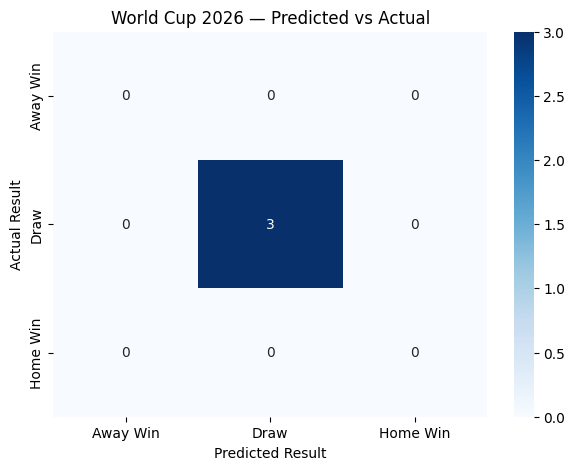

In [242]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ['Away Win', 'Draw', 'Home Win']

cm = confusion_matrix(
    comparison['Actual Result'],
    comparison['Predicted Result'],
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted Result')
plt.ylabel('Actual Result')
plt.title('World Cup 2026 — Predicted vs Actual')
plt.show()

In [245]:
missing_from_predictions = actual_results.merge(
    predictions,
    on=['team_a_clean', 'team_b_clean'],
    how='left',
    indicator=True
)

missing_from_predictions = missing_from_predictions[
    missing_from_predictions['_merge'] == 'left_only'
]

print("Matches missing from predictions:", len(missing_from_predictions))

display(
    missing_from_predictions[
        ['Team A_x', 'Team B_x', 'Date_x', '90-Minute Result']
    ]
)


Matches missing from predictions: 10


,Team A_x,Team B_x,Date_x,90-Minute Result
5,Australia,Türkiye,2026-06-14,Team A Win
9,Germany,Curaçao,2026-06-14,Team A Win
22,Portugal,Congo DR,2026-06-17,Draw
30,Türkiye,Paraguay,2026-06-20,Team B Win
33,Ecuador,Curaçao,2026-06-21,Draw
47,Colombia,Congo DR,2026-06-24,Team A Win
54,Curaçao,Côte d'Ivoire,2026-06-25,Team B Win
58,Türkiye,United States,2026-06-26,Team A Win
71,Congo DR,Uzbekistan,2026-06-27,Team A Win
79,England,Congo DR,2026-07-01,Team A Win


In [247]:
missing_from_actual = predictions.merge(
    actual_results,
    on=['team_a_clean', 'team_b_clean'],
    how='left',
    indicator=True
)

missing_from_actual = missing_from_actual[
    missing_from_actual['_merge'] == 'left_only'
]

print("Predictions without actual results:", len(missing_from_actual))

display(
    missing_from_actual[
        ['team_A', 'team_B', 'match_date', 'Predicted Result']
    ]
)

Predictions without actual results: 10


,team_A,team_B,match_date,Predicted Result
19,australia,turkiye,2026-06-13,Draw
20,turkiye,paraguay,2026-06-19,Team B Win
22,turkiye,united states,2026-06-25,Team B Win
25,germany,curacao,2026-06-14,Team A Win
27,ecuador,curacao,2026-06-20,Draw
28,curacao,ivory coast,2026-06-25,Draw
60,portugal,dr congo,2026-06-17,Team A Win
63,colombia,dr congo,2026-06-23,Team A Win
65,dr congo,uzbekistan,2026-06-27,Team A Win
79,england,dr congo,2026-07-01,Team A Win


In [248]:
print(
    actual_results[
        actual_results['Team A'].astype(str).str.lower().str.contains('congo', na=False) |
        actual_results['Team B'].astype(str).str.lower().str.contains('congo', na=False)
    ][['Team A', 'Team B']].drop_duplicates()
)

      Team A      Team B
22  Portugal    Congo DR
47  Colombia    Congo DR
71  Congo DR  Uzbekistan
79   England    Congo DR


In [249]:
def standardize_team_name(x):
    x = str(x).strip().lower()

    # remove accents
    import unicodedata
    x = ''.join(
        c for c in unicodedata.normalize('NFKD', x)
        if not unicodedata.combining(c)
    )

    # remove punctuation
    x = x.replace('.', '').replace('-', ' ').replace('_', ' ')
    x = ' '.join(x.split())

    aliases = {
        'turkey': 'turkiye',
        'türkiye': 'turkiye',

        'curacao': 'curacao',

        'dr congo': 'dr congo',
        'drc': 'dr congo',
        'congo dr': 'dr congo',
        'democratic republic of the congo': 'dr congo',
        'democratic republic of congo': 'dr congo',

        'korea republic': 'south korea',
        'republic of korea': 'south korea',

        'czechia': 'czech republic',

        'cote divoire': 'ivory coast',
        "cote d'ivoire": 'ivory coast',
    }

    return aliases.get(x, x)

In [251]:
predictions['team_a_clean'] = predictions['team_A'].apply(
    standardize_team_name
)

predictions['team_b_clean'] = predictions['team_B'].apply(
    standardize_team_name
)

actual_results['team_a_clean'] = actual_results['Team A'].apply(
    standardize_team_name
)

actual_results['team_b_clean'] = actual_results['Team B'].apply(
    standardize_team_name
)

In [253]:
missing_from_actual = predictions.merge(
    actual_results,
    on=['team_a_clean', 'team_b_clean'],
    how='left',
    indicator=True
)

missing_from_actual = missing_from_actual[
    missing_from_actual['_merge'] == 'left_only'
]

print(
    "Predictions without actual results:",
    len(missing_from_actual)
)

display(
    missing_from_actual[
        ['team_A', 'team_B', 'match_date', 'Predicted Result']
    ]
)


Predictions without actual results: 0


,team_A,team_B,match_date,Predicted Result


In [254]:
# Keep the authoritative comparison above; do not use a team-only many-to-many merge.
comparison = comparison.copy()
print('Total matched matches:', len(comparison))

Total matched matches: 63


In [255]:
comparison['Correct'] = (
    comparison['Predicted Result'] ==
    comparison['Actual Result']
)

print("Correct predictions:", comparison['Correct'].sum())
print("Incorrect predictions:", (~comparison['Correct']).sum())

Correct predictions: 39
Incorrect predictions: 24


In [256]:
accuracy = comparison['Correct'].mean()

print(f"World Cup 2026 Prediction Accuracy: {accuracy:.4f}")
print(f"World Cup 2026 Prediction Accuracy: {accuracy * 100:.2f}%")

World Cup 2026 Prediction Accuracy: 0.6190
World Cup 2026 Prediction Accuracy: 61.90%


In [258]:
display(
    comparison[
        [
            'match_date',
            'team_A',
            'team_B',
            'Predicted Result',
            'Actual Result',
            'Correct'
        ]
    ]
)

,match_date,team_A,team_B,Predicted Result,Actual Result,Correct
0,2026-06-11,mexico,south africa,Team A Win,Team A Win,True
1,2026-06-18,czech republic,south africa,Team B Win,Draw,False
2,2026-06-12,canada,bosnia and herzegovina,Team A Win,Draw,False
3,2026-06-13,qatar,switzerland,Draw,Draw,True
4,2026-06-18,switzerland,bosnia and herzegovina,Team A Win,Team A Win,True
...,...,...,...,...,...,...
58,2026-07-11,norway,england,Draw,Team B Win,False
59,2026-07-14,france,spain,Draw,Team B Win,False
60,2026-07-15,england,argentina,Team B Win,Team B Win,True
61,2026-07-18,france,england,Team B Win,Team B Win,True


In [259]:
from sklearn.metrics import classification_report

print("World Cup 2026 Classification Report:\n")

print(
    classification_report(
        comparison['Actual Result'],
        comparison['Predicted Result']
    )
)

World Cup 2026 Classification Report:

              precision    recall  f1-score   support

        Draw       0.33      0.19      0.24        16
  Team A Win       0.71      0.80      0.75        30
  Team B Win       0.60      0.71      0.65        17

    accuracy                           0.62        63
   macro avg       0.55      0.56      0.55        63
weighted avg       0.58      0.62      0.59        63



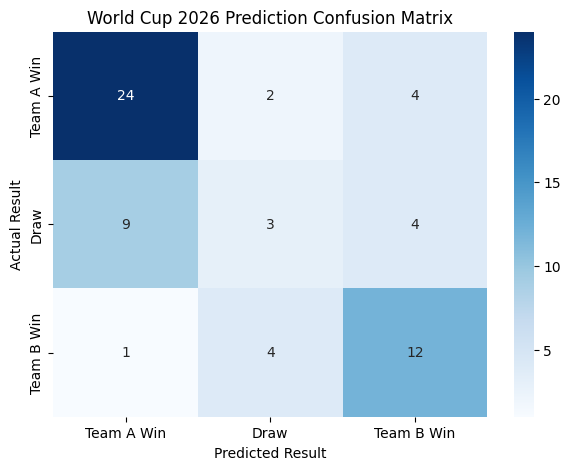

In [263]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['Team A Win', 'Draw', 'Team B Win']

cm = confusion_matrix(
    comparison['Actual Result'],
    comparison['Predicted Result'],
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted Result')
plt.ylabel('Actual Result')
plt.title('World Cup 2026 Prediction Confusion Matrix')
plt.show()

In [261]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_macro_f1 = f1_score(y_test, y_pred_lr, average='macro')

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("Logistic Regression Macro F1:", round(lr_macro_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=le_compare.classes_
))

Logistic Regression Accuracy: 0.5492
Logistic Regression Macro F1: 0.5137

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.27      0.28      0.28      1110
        Draw       0.63      0.63      0.63      1811
    Home Win       0.64      0.63      0.63      1886

    accuracy                           0.55      4807
   macro avg       0.51      0.51      0.51      4807
weighted avg       0.55      0.55      0.55      4807



In [262]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_macro_f1 = f1_score(y_test, y_pred_xgb, average='macro')

print("XGBoost Accuracy:", round(xgb_accuracy, 4))
print("XGBoost Macro F1:", round(xgb_macro_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=le_compare.classes_
))

XGBoost Accuracy: 0.575
XGBoost Macro F1: 0.4389

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.40      0.01      0.02      1110
        Draw       0.57      0.74      0.64      1811
    Home Win       0.58      0.75      0.66      1886

    accuracy                           0.57      4807
   macro avg       0.52      0.50      0.44      4807
weighted avg       0.54      0.57      0.50      4807

